# CTU-UHB Step 2+3 Multiclass Short Experiment Plan


Minimal refactor of the CTU-UHB multiclass pipeline for a focused dissertation-ready experiment.


## Goal

Improve **step-level / record-step 3-class performance**, especially **Mild recall**, while keeping grouped cross-validation by `rec_id` and the existing preprocessing logic.


## Minimal changes in this version

- Drop **Step 1** entirely

- Train and evaluate on **Step 2 + Step 3** 30-minute windows only, using **3 controlled windows per step**

- Increase the window-quality threshold to **`max_nan_fraction = 0.16`**

- Keep the standard **3-class softmax** CNN as the primary model

- Add a compact **engineered-feature branch** alongside the raw-signal CNN branch

- Standardize engineered features using **training-fold statistics only**

- Keep **grouped CV by `rec_id`** but evaluate at the **record-step level** rather than collapsing back to one label per record


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    REPO_DIR = '/content/Deep_Learning_Based_Classification_of_Cardiotograms_for_Predicting_Birth_Outcomes'

    if not os.path.exists(REPO_DIR):
        !git clone -b helper https://github.com/zeyneppguler23/Deep_Learning_Based_Classification_of_Cardiotograms_for_Predicting_Birth_Outcomes.git

    os.chdir(os.path.join(REPO_DIR, 'src', 'Transfer_Learning'))
    !pip install -q imbalanced-learn wfdb
    print(f"Working directory: {os.getcwd()}")
else:
    print("Not on Colab skipping setup.")

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled. prevents ResourceExhausted errors.")
else:
    print("WARNING: No GPU found.")

Cloning into 'Deep_Learning_Based_Classification_of_Cardiotograms_for_Predicting_Birth_Outcomes'...
remote: Enumerating objects: 4116, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 4116 (delta 64), reused 115 (delta 27), pack-reused 3959 (from 2)
Receiving objects: 100% (4116/4116), 235.60 MiB | 33.36 MiB/s, done.
Resolving deltas: 100% (1184/1184), done.
Updating files: 100% (3425/3425), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 129.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requi

## 1. Imports

In [86]:
# Disable oneDNN/MKL ops BEFORE importing TF
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Core
import numpy as np
import pandas as pd
from pathlib import Path
import wfdb
import json
import warnings
from typing import Dict, List, Tuple

# Signal processing
from scipy.interpolate import interp1d
from scipy.signal import welch

# Sklearn
from sklearn.metrics import (
    confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
 )
from sklearn.utils.class_weight import compute_class_weight

# Try to import StratifiedGroupKFold (sklearn >= 1.0)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available - will use group-aware stratified splitting.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False
    print("WARNING: StratifiedGroupKFold not available (sklearn < 1.0).")
    print("         Falling back to GroupKFold - class balance across folds not guaranteed.")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, Dropout, GlobalAveragePooling1D, Dense,
    Concatenate, Reshape, Multiply, Add,
    # 2D layers for CTG-Net (Zhao et al.)
    Conv2D, DepthwiseConv2D, SeparableConv2D,
    AveragePooling2D, Flatten,
 )
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
 )
from tensorflow.keras.utils import to_categorical

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

StratifiedGroupKFold available - will use group-aware stratified splitting.
TensorFlow 2.19.0 | NumPy 2.0.2
GPU available: True


## 2. Configuration

All experiment parameters in one place. Change values here to toggle between
from-scratch training and transfer learning, adjust segmentation, etc.

In [3]:
# PATHS

RAW_DATASET   = Path("../data/raw_dataset")
STEP2_LABELS  = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS  = Path("../ExpertAnnotations/step3_labels.csv")
OUTPUT_DIR    = Path("outputs/step23_softmax_short_plan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Signal Parameters
RAW_SAMPLING_RATE      = 4
TARGET_SAMPLING_RATE   = 1
DOWNSAMPLE_FACTOR      = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE
WINDOW_MINUTES  = 30
WINDOW_LENGTH   = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE
# Keep the existing key names from before.
SAMPLING_RATE   = TARGET_SAMPLING_RATE
SEGMENT_MINUTES = WINDOW_MINUTES
SEGMENT_LENGTH  = WINDOW_LENGTH

In [5]:
#label definitions

NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

In [6]:
#training/experiment configuration

CFG = dict(
    # Step-window experiment scope
    step_numbers            = [2, 3],
    mode_a_offsets          = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes         = SEGMENT_MINUTES,
    segment_length          = SEGMENT_LENGTH,
    max_nan_fraction        = 0.16,
    pad_short_records       = False,

    # Cross-validation
    n_splits                = 10,
    cv_seed                 = 42,
    min_severe_records      = 10,
    max_cv_attempts         = 100,

    # Model architecture
    temporal_filters        = 32,
    temporal_kernel         = 7,
    separable_filters       = 32,
    separable_kernels       = [3, 7, 15],
    projection_filters      = 32,
    dropout_rate            = 0.40,

    # Engineered-feature branch
    use_clinical_features   = True,

    # Augmentation pipeline
    augment_train           = True,
    aug_time_warp           = True,
    aug_warp_sigma          = 0.10,
    aug_amplitude_scale     = True,
    aug_amp_sigma           = 0.10,
    aug_noise               = True,
    aug_noise_std           = 0.02,
    aug_signal_loss         = True,
    aug_gap_frac            = 0.05,
    aug_n_gaps              = 2,

    # Scratch training
    scratch_epochs          = 100,
    scratch_lr              = 1e-3,
    scratch_batch           = 16,
    scratch_patience        = 20,
    label_smoothing         = 0.05,
    use_class_weights       = True,
)

windows_per_step = {step_num: len(offsets) for step_num, offsets in CFG['controlled_step_offsets'].items()}
if len(set(windows_per_step.values())) != 1:
    raise ValueError(f"All steps must use the same number of controlled windows, got: {windows_per_step}")

CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))


print("CONFIGURATION SUMMARY")

print(f"Windows used:Steps {CFG['step_numbers']}")
print(f"Sampling rate:{RAW_SAMPLING_RATE} Hz raw -> {SAMPLING_RATE} Hz model input")
print(f"Window length:{CFG['segment_minutes']} min = {CFG['segment_length']} samples @ {SAMPLING_RATE} Hz")
print(f"Canonical offsets:{CFG['mode_a_offsets']}")
print(f"Controlled windows:{CONTROLLED_WINDOWS_PER_STEP} per step")
for step_num in CFG['step_numbers']:
    print(f"Step {step_num}:{CFG['controlled_step_offsets'][step_num]}")
print(f"Max NaN frac:{CFG['max_nan_fraction']:.0%}")
print(f"CV folds: {CFG['n_splits']}")
print(f"Requested min Severe/fold: {CFG['min_severe_records']} step-units")
print(f"Label smoothing: {CFG['label_smoothing']:.2f}")
print(f"Softmax baseline: enabled")
print(f"Feature branch: 10 time-domain engineered FHR features")
print(f"Grouped CV: by rec_id (unchanged)")

CONFIGURATION SUMMARY
Windows used:Steps [2, 3]
Sampling rate:4 Hz raw -> 1 Hz model input
Window length:30 min = 1800 samples @ 1 Hz
Canonical offsets:{2: (60, 30), 3: (30, 0)}
Controlled windows:3 per step
Step 2:[(70, 40), (60, 30), (50, 20)]
Step 3:[(50, 20), (40, 10), (30, 0)]
Max NaN frac:16%
CV folds: 10
Requested min Severe/fold: 10 step-units
Label smoothing: 0.05
Softmax baseline: enabled
Feature branch: 10 time-domain engineered FHR features
Grouped CV: by rec_id (unchanged)


## 4. Step-Window Extraction (Steps 2 + 3 Only)



**Strategy:**

- Extract only the **Step 2** and **Step 3** 30-minute delivery-anchored windows

- For each eligible record-step, create a fixed set of **3 controlled windows**

- Keep **grouping by `rec_id`** unchanged so all windows from one record stay in the same fold

- Reject the entire record-step if any controlled window is too short or exceeds the missing-data threshold

- Track `rec_id` and window metadata so validation predictions are still aggregated at the **record level**


In [7]:
#data loading and FHR cleaning section

def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:
    """Load Step 2 and Step 3 labels independently and filter uninterpretable rows."""
    step_labels = {}
    for step_num, path in step_paths.items():
        df = pd.read_csv(path)
        total = len(df)
        df = df[df['Majority_Vote_Label'] != -1].copy()
        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)
        df['rec_id'] = df['rec_id'].astype(str)
        excluded = total - len(df)
        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")
        for cls_id, name in enumerate(CLASS_NAMES):
            n = int((df['class_id'] == cls_id).sum())
            print(f"  Class {cls_id} ({name}): {n} ({n / max(len(df), 1) * 100:.1f}%)")
        step_labels[step_num] = df
    return step_labels

In [8]:
def remove_trailing_zeros(signal) -> list:
    """Remove trailing zeros (marks end of recording / delivery)."""
    sig = list(signal) if isinstance(signal, np.ndarray) else list(signal)
    i = len(sig) - 1
    while i >= 0 and sig[i] == 0:
        i -= 1
    return sig[:i + 1]

In [9]:
def clean_fhr(fhr_array, fs: int = 4) -> np.ndarray:
    """
    Clean a fetal heart rate signal using the existing pipeline.
    """
    fhr = pd.Series(np.array(fhr_array, dtype=float))
    # Replace 0 with NaN
    fhr.replace(0, np.nan, inplace=True)
    # Remove NaN gaps > 15 consecutive seconds
    na = fhr.isnull()
    gap_groups = na.ne(na.shift()).cumsum()
    gap_sizes = fhr.groupby(gap_groups.values).transform('size')
    fhr = fhr[~(gap_sizes.ge(fs * 15 + 1) & na)].reset_index(drop=True)
    # Outlier detection
    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan
    #Linear interpolation
    fhr = fhr.interpolate(method='linear')
    # Spike detection and removal
    diff = fhr - fhr.shift()
    fhr[(diff > 25) | (diff < -25)] = np.nan
    fhr = fhr.interpolate(method='linear')
    # Edge NaN fill
    fhr = fhr.ffill().bfill()
    return fhr.values

In [10]:
def downsample_signal(signal: np.ndarray, factor: int = 4) -> np.ndarray:
    """Downsample a cleaned 1D signal by simple decimation."""
    if factor <= 1:
        return np.asarray(signal, dtype=np.float32)
    return np.asarray(signal[::factor], dtype=np.float32)

In [103]:
def load_raw_signals(dataset_path: Path) -> Dict[str, dict]:
    """
    Load all CTU-UHB records, clean FHR and UC at native 4 Hz, then downsample to 1 Hz.
    Returns: dict[rec_id] = {'FHR': np.ndarray, 'UC': np.ndarray, 'length': int}
    """
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files in {dataset_path}")

    data = {}

    for rid in sorted(records):
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            fhr_raw = remove_trailing_zeros(rec.p_signal[:, 0].tolist())
            fhr_clean = clean_fhr(fhr_raw, fs=RAW_SAMPLING_RATE)
            fhr_downsampled = downsample_signal(fhr_clean, factor=DOWNSAMPLE_FACTOR)

            uc_raw = remove_trailing_zeros(rec.p_signal[:, 1].tolist())
            uc_clean = clean_uc(uc_raw, fs=RAW_SAMPLING_RATE)
            uc_downsampled = downsample_signal(uc_clean, factor=DOWNSAMPLE_FACTOR)

            # Align lengths (use shorter of the two after independent trailing-zero removal)
            min_len = min(len(fhr_downsampled), len(uc_downsampled))
            fhr_downsampled = fhr_downsampled[:min_len]
            uc_downsampled = uc_downsampled[:min_len]

            data[rid] = {
                'FHR': fhr_downsampled,
                'UC': uc_downsampled,
                'length': min_len,
            }

        except Exception as e:
            print(f"  Skipping {rid}: {e}")

    print(f"\nLoaded {len(data)} FHR + UC signals")
    lengths = [d['length'] for d in data.values()]
    print(f"Duration range: {min(lengths)/(SAMPLING_RATE*60):.1f} – {max(lengths)/(SAMPLING_RATE*60):.1f} minutes")
    return data

In [104]:
#Load data
STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}
step_label_dfs = load_step_labels(STEP_LABEL_PATHS)
signal_data = load_raw_signals(RAW_DATASET)

labelled_rec_ids = set()
for df in step_label_dfs.values():
    labelled_rec_ids.update(df['rec_id'].tolist())

valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))
print(f"\nRecords with at least one Step 2/3 label and a signal: {len(valid_rec_ids)}")

Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127 (37.7%)
  Class 1 (Mild): 153 (45.4%)
  Class 2 (Severe): 57 (16.9%)
Found 552 .hea files in ../data/raw_dataset

Loaded 552 FHR + UC signals
Duration range: 0.0 – 90.1 minutes

Records with at least one Step 2/3 label and a signal: 549


## 4. Step-Window Construction at 1 Hz

**Strategy:**
- Clean raw FHR at its native **4 Hz**, then downsample to **1 Hz** for modeling.
- Extract a fixed set of **3 controlled 30-minute windows per eligible step** rather than a single canonical window.
- Step 2 uses earlier / canonical / later offsets around the canonical interval; Step 3 is delivery-bounded, so its three windows run from earlier coverage up to the canonical delivery window.
- If any of the 3 controlled windows for a record-step is too short or fails the missing-data threshold, that record-step is dropped entirely.
- The `group` array still tracks the parent `rec_id` for every window, so grouped CV remains leakage-free and validation windows are still aggregated back to the record level.

In [13]:
# step-window extraction section step 2 and 3

def _window_bounds_from_end(
    sig_len: int,
    offsets_from_end_min: Tuple[int, int],
    fs: int = 4,
):
    """Return sample bounds for one delivery-anchored window."""
    start_from_end_min, end_from_end_min = offsets_from_end_min

    if start_from_end_min <= end_from_end_min:
        raise ValueError(
            f"Expected start offset > end offset, got {offsets_from_end_min}"
        )

    start_from_end = start_from_end_min * 60 * fs
    end_from_end = end_from_end_min * 60 * fs

    if sig_len < start_from_end:
        return None

    start_idx = sig_len - start_from_end
    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len

    if end_idx <= start_idx:
        return None

    return int(start_idx), int(end_idx)


In [14]:
def _get_controlled_window_bounds(
    sig_len: int,
    step_num: int,
    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],
    fs: int = 4,
):
    """Return all controlled window bounds for one record-step."""
    if step_num not in controlled_step_offsets:
        raise KeyError(f"Missing controlled offsets for step {step_num}")

    bounds = []
    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):
        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)
        if cur_bounds is None:
            return None

        start_idx, end_idx = cur_bounds
        bounds.append((window_index, offsets, start_idx, end_idx))

    return bounds

In [15]:
def create_step_windows(
    signal_data: Dict[str, dict],
    step_label_dfs: Dict[int, pd.DataFrame],
    record_ids: List[str],
    window_length: int = 7200,
    step_numbers=None,
    step_offsets=None,
    controlled_step_offsets=None,
    max_nan_fraction: float = 0.16,
    pad_short_records: bool = False,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Extract controlled Step 2 and Step 3 30-minute windows from cleaned CTU-UHB FHR signals.
    """
    if step_numbers is None:
        step_numbers = [2, 3]

    if step_offsets is None:
        step_offsets = {2: (60, 30), 3: (30, 0)}

    if controlled_step_offsets is None:
        controlled_step_offsets = {
            step_num: [step_offsets[step_num]]
            for step_num in step_numbers
        }

    windows_per_step = {
        step_num: len(controlled_step_offsets[step_num])
        for step_num in step_numbers
    }
    if len(set(windows_per_step.values())) != 1:
        raise ValueError(
            f"All steps must use the same number of controlled windows, got: {windows_per_step}"
        )

    fixed_windows_per_step = next(iter(windows_per_step.values()))

    X_list = []
    y_list = []
    group_list = []
    meta_list = []

    accepted_record_steps = 0
    skipped_step_short = 0
    skipped_step_nan = 0

    for rid in record_ids:
        if rid not in signal_data:
            continue

        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)
        sig_len = len(fhr)

        for step_num in step_numbers:
            step_df = step_label_dfs.get(step_num)
            if step_df is None:
                continue

            row = step_df[step_df['rec_id'] == rid]
            if row.empty:
                continue

            controlled_bounds = _get_controlled_window_bounds(
                sig_len,
                step_num,
                controlled_step_offsets,
                fs=fs,
            )
            if controlled_bounds is None:
                skipped_step_short += 1
                continue

            label = int(row['class_id'].iloc[0])
            step_windows = []
            step_failed_short = False
            step_failed_nan = False

            for window_index, offsets, start_idx, end_idx in controlled_bounds:
                window = fhr[start_idx:end_idx]

                if len(window) < window_length:
                    if pad_short_records:
                        pad_len = window_length - len(window)
                        window = np.pad(window, (pad_len, 0), mode='edge')
                    else:
                        step_failed_short = True
                        break

                missing_frac_prefill = float(np.mean(np.isnan(window) | (window == 0)))
                if missing_frac_prefill > max_nan_fraction:
                    step_failed_nan = True
                    break

                if np.any(np.isnan(window)):
                    s = pd.Series(window)
                    window = s.interpolate(method='linear').ffill().bfill().values

                step_windows.append(
                    {
                        'window': window.astype(np.float32),
                        'window_index': window_index,
                        'offset_start_min': int(offsets[0]),
                        'offset_end_min': int(offsets[1]),
                        'window_start': start_idx,
                        'window_end': end_idx,
                        'missing_frac_prefill': missing_frac_prefill,
                    }
                )

            if step_failed_short:
                skipped_step_short += 1
                continue

            if step_failed_nan:
                skipped_step_nan += 1
                continue

            if len(step_windows) != fixed_windows_per_step:
                raise RuntimeError(
                    f"Expected {fixed_windows_per_step} windows for {rid} step {step_num}, "
                    f"got {len(step_windows)}"
                )

            accepted_record_steps += 1
            for step_window in step_windows:
                X_list.append(step_window['window'])
                y_list.append(label)
                group_list.append(rid)
                meta_list.append(
                    {
                        'rec_id': rid,
                        'step': step_num,
                        'window_index': step_window['window_index'],
                        'offset_start_min': step_window['offset_start_min'],
                        'offset_end_min': step_window['offset_end_min'],
                        'window_start': step_window['window_start'],
                        'window_end': step_window['window_end'],
                        'label': label,
                        'missing_frac_prefill': step_window['missing_frac_prefill'],
                    }
                )

    if X_list:
        X_windows = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]
    else:
        X_windows = np.empty((0, window_length, 1), dtype=np.float32)

    y_windows = np.array(y_list, dtype=np.int32)
    groups = np.array(group_list)
    metadata = pd.DataFrame(meta_list)

    print("\nStep-window extraction complete:")
    print(f"Total windows: {len(X_windows)} from {len(set(group_list))} records")
    print(f"Window shape:{X_windows.shape}")
    print(f"Controlled windows/step:{fixed_windows_per_step}")
    print(f"Accepted record-steps:{accepted_record_steps}")
    print(f"Skipped record-steps (short): {skipped_step_short}")
    print(f"Skipped record-steps (NaN):{skipped_step_nan}")

    if len(metadata) > 0:
        for step_num in step_numbers:
            step_mask = metadata['step'] == step_num
            n_step_windows = int(step_mask.sum())
            n_step_records = int(metadata.loc[step_mask, 'rec_id'].nunique())
            print(f"  Step {step_num}:               {n_step_windows} windows from {n_step_records} records")

        for cls_id, name in enumerate(CLASS_NAMES):
            n_class = int(np.sum(y_windows == cls_id))
            print(f"  Class {cls_id} ({name}):      {n_class} windows")

    return X_windows, y_windows, groups, metadata


# Create Step 2 + Step 3 windows from all valid records
print("Creating Step 2 + Step 3 controlled 30-minute windows...")

X_all, y_all, groups_all, meta_all = create_step_windows(
    signal_data=signal_data,
    step_label_dfs=step_label_dfs,
    record_ids=valid_rec_ids,
    window_length=CFG['segment_length'],
    step_numbers=CFG['step_numbers'],
    step_offsets=CFG['mode_a_offsets'],
    controlled_step_offsets=CFG['controlled_step_offsets'],
    max_nan_fraction=CFG['max_nan_fraction'],
    pad_short_records=CFG['pad_short_records'],
    fs=SAMPLING_RATE,
)

windows_per_record = pd.Series(groups_all).value_counts()
if len(windows_per_record) > 0:
    print(
        f"\nWindows per record: min={windows_per_record.min()}, max={windows_per_record.max()}, mean={windows_per_record.mean():.1f}"
    )
    print("Step counts:")
    print(meta_all['step'].value_counts().sort_index())
    print("Window index counts:")
    print(meta_all['window_index'].value_counts().sort_index())

Creating Step 2 + Step 3 controlled 30-minute windows...

Step-window extraction complete:
Total windows: 1398 from 336 records
Window shape:(1398, 1800, 1)
Controlled windows/step:3
Accepted record-steps:466
Skipped record-steps (short): 419
Skipped record-steps (NaN):0
  Step 2:               399 windows from 133 records
  Step 3:               999 windows from 333 records
  Class 0 (Normal):      564 windows
  Class 1 (Mild):      636 windows
  Class 2 (Severe):      198 windows

Windows per record: min=3, max=6, mean=4.2
Step counts:
step
2    399
3    999
Name: count, dtype: int64
Window index counts:
window_index
0    466
1    466
2    466
Name: count, dtype: int64


## 6. Normalization, Augmentation & Engineered Features



**Normalization:** Z-score statistics are computed from the **training fold only**.



**Time-Series Augmentations** remain unchanged and are applied to training windows only.



**Compact engineered features** are extracted from the cleaned 30-minute FHR window:

1. mean

2. median

3. std

4. IQR

5. mean absolute successive difference

6. std of 1-minute means

7. number of accelerations

8. number of decelerations

9. max deceleration depth

10. fraction of missing/invalid samples before final fill


In [16]:
#leakage safe normalisation, augmentation, engineered features

def compute_norm_stats(X_train: np.ndarray) -> dict:
    """Compute mean and std from training windows only."""
    vals = X_train.ravel()
    mean = float(np.mean(vals))
    std = float(np.std(vals))
    if std < 1e-8:
        std = 1.0
    return {'mean': mean, 'std': std}

In [17]:
def apply_norm(X: np.ndarray, stats: dict) -> np.ndarray:
    """Apply pre-computed z-score normalization."""
    X_norm = X.astype(np.float32)
    X_norm -= stats['mean']
    X_norm /= stats['std']
    return X_norm

In [18]:
#time series augmentations, applied to training data only
def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    """Time warping: stretch/compress the time axis by smooth random amounts."""
    N, T, C = X.shape
    X_warped = np.empty_like(X)
    orig_steps = np.arange(T)
    n_knots = 4
    knot_pos = np.linspace(0, T - 1, n_knots + 2)

    for i in range(N):
        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)
        warp_factors[0] = 1.0
        warp_factors[-1] = 1.0
        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])
        warped_knots = np.concatenate([[0], warped_knots])
        warped_knots = warped_knots / warped_knots[-1] * (T - 1)
        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')
        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)

        for c in range(C):
            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')
            X_warped[i, :, c] = interp_sig(warped_steps)

    return X_warped.astype(np.float32)

In [19]:
def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    """Random per-sample amplitude scaling."""
    N = X.shape[0]
    scales = np.random.normal(1.0, sigma, size=(N, 1, 1)).astype(np.float32)
    return X * scales

In [20]:
def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:
    """Add mild Gaussian noise."""
    noise = np.random.normal(0, noise_std, X.shape).astype(np.float32)
    return X + noise

In [21]:
def signal_loss_simulation(X: np.ndarray,max_gap_frac: float = 0.05,n_gaps: int = 2,) -> np.ndarray:
    """Simulate random signal dropout with interpolation across short gaps."""
    N, T, C = X.shape
    X_aug = X.copy()
    max_gap = max(1, int(T * max_gap_frac))

    for i in range(N):
        for _ in range(n_gaps):
            gap_len = np.random.randint(1, max_gap + 1)
            start = np.random.randint(0, T - gap_len)
            end = start + gap_len
            for c in range(C):
                left_val = X_aug[i, max(start - 1, 0), c]
                right_val = X_aug[i, min(end, T - 1), c]
                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)

    return X_aug.astype(np.float32)

In [22]:
def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:
    """Apply the unchanged augmentation pipeline to training data only."""
    X_aug = X.copy()
    if cfg.get('aug_time_warp', True):
        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))
    if cfg.get('aug_amplitude_scale', True):
        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))
    if cfg.get('aug_noise', True):
        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))
    if cfg.get('aug_signal_loss', True):
        X_aug = signal_loss_simulation(
            X_aug,
            max_gap_frac=cfg.get('aug_gap_frac', 0.05),
            n_gaps=cfg.get('aug_n_gaps', 2),)

    return X_aug

In [23]:
# Engineered feature extraction

def compute_clinical_features(X: np.ndarray,fs: int = 4,missing_frac_prefill=None,) -> np.ndarray:
    """
    Extract a compact engineered feature vector from each cleaned FHR window.

    Features:
      1. mean
      2. median
      3. std
      4. IQR
      5. mean absolute successive difference
      6. std of 1-minute means
      7. number of accelerations
      8. number of decelerations
      9. max deceleration depth
     10. fraction of missing/invalid samples before final fill
    """

    N, T, _ = X.shape
    features = np.zeros((N, 10), dtype=np.float32)
    min_dur_samples = 15 * fs
    one_min_samples = 60 * fs

    if missing_frac_prefill is None:
        missing_frac_prefill = np.zeros(N, dtype=np.float32)
    else:
        missing_frac_prefill = np.asarray(missing_frac_prefill, dtype=np.float32)
    for i in range(N):
        sig = np.asarray(X[i, :, 0], dtype=np.float64)
        baseline = float(np.median(sig))
        deviation = sig - baseline
        features[i, 0] = float(np.mean(sig))
        features[i, 1] = float(np.median(sig))
        features[i, 2] = float(np.std(sig))
        q25, q75 = np.percentile(sig, [25, 75])
        features[i, 3] = float(q75 - q25)
        features[i, 4] = float(np.mean(np.abs(np.diff(sig)))) if len(sig) > 1 else 0.0
        n_minutes = T // one_min_samples
        if n_minutes >= 2:
            minute_means = [
                np.mean(sig[j * one_min_samples:(j + 1) * one_min_samples])
                for j in range(n_minutes)
            ]
            features[i, 5] = float(np.std(minute_means))
        else:
            features[i, 5] = features[i, 2]
        accel_mask = deviation >= 15
        decel_mask = deviation <= -15
        accel_count, _ = _count_episodes(deviation, accel_mask, min_dur_samples)
        decel_count, _ = _count_episodes(-deviation, decel_mask, min_dur_samples)
        features[i, 6] = float(accel_count)
        features[i, 7] = float(decel_count)
        features[i, 8] = float(np.max(np.maximum(-deviation, 0.0)))
        features[i, 9] = float(missing_frac_prefill[i])
    return features

In [24]:
def _count_episodes(deviation: np.ndarray,mask: np.ndarray,min_dur: int,) -> tuple:
    """Count episodes where mask is True for at least min_dur consecutive samples."""
    count = 0
    total_area = 0.0
    in_episode = False
    episode_start = 0

    for j in range(len(mask)):
        if mask[j] and not in_episode:
            in_episode = True
            episode_start = j
        elif not mask[j] and in_episode:
            in_episode = False
            dur = j - episode_start
            if dur >= min_dur:
                count += 1
                total_area += float(np.sum(np.abs(deviation[episode_start:j])))
    if in_episode:
        dur = len(mask) - episode_start
        if dur >= min_dur:
            count += 1
            total_area += float(np.sum(np.abs(deviation[episode_start:])))
    return count, total_area

In [25]:
# Unified feature computation

def compute_all_engineered_features(
    X: np.ndarray,
    fs: int = 1,
    missing_frac_prefill=None,
) -> np.ndarray:
    """Compute the 10 time-domain engineered features for each FHR window."""
    return compute_clinical_features(X, fs=fs, missing_frac_prefill=missing_frac_prefill)


print("compute_all_engineered_features() defined – 10 time-domain features")

compute_all_engineered_features() defined – 10 time-domain features


In [26]:
# 10 time-domain engineered feature names
ALL_FEATURE_NAMES = [
    'mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd',
    'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill',
]

CLINICAL_FEATURE_NAMES = ALL_FEATURE_NAMES
N_CLINICAL_FEATURES = len(ALL_FEATURE_NAMES)

print(f"{N_CLINICAL_FEATURES} engineered features: {ALL_FEATURE_NAMES}")

10 engineered features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']


In [27]:
def normalize_clinical_features(feats_train: np.ndarray,feats_apply: np.ndarray,) -> tuple:
    """Z-score normalize engineered features using TRAIN statistics only."""
    mean = feats_train.mean(axis=0)
    std = feats_train.std(axis=0)
    std[std < 1e-8] = 1.0
    return (feats_apply - mean) / std, {'mean': mean, 'std': std}

In [28]:
print("Normalization, augmentation & engineered-feature utilities defined:")
print(f"All features ({N_CLINICAL_FEATURES}): {ALL_FEATURE_NAMES}")
print("augment_signal() remains unchanged and is applied to training windows only")

# Quick smoke test: compute features on first 5 windows
if 'X_all' in globals() and len(X_all) >= 5:
    _test_X = X_all[:5]
    _test_mfp = meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32)[:5]
    _feats = compute_all_engineered_features(_test_X, fs=SAMPLING_RATE, missing_frac_prefill=_test_mfp)
    print(f"  Smoke test: shape={_feats.shape}, features={ALL_FEATURE_NAMES}")
    del _test_X, _test_mfp, _feats
    print("Smoke test passed.")

Normalization, augmentation & engineered-feature utilities defined:
All features (10): ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
augment_signal() remains unchanged and is applied to training windows only
  Smoke test: shape=(5, 10), features=['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
Smoke test passed.


## 7. Model Architecture

A compact 1D CNN with multi-scale separable convolutions, squeeze-excitation attention,
and a residual block. Uses `GlobalAveragePooling1D` so the model stays length-agnostic.

**Final layer:** `Dense(3, activation='softmax')` for the 3-class step-level classification task.

The optional engineered-feature branch is fused after the raw-signal branch and is trained
jointly in the same scratch-only pipeline used by the current experiment.

In [29]:
# model architecture
def _se_block_1d(x, ratio: int = 4, name: str = "se"):
    """
    Squeeze-and-Excitation (SE) attention block for 1D signals.
    Learns per-channel importance weights via global average pooling.
    Input:  (batch, time_steps, channels)
    Output: (batch, time_steps, channels) - same shape, re-weighted
    """
    filters = int(x.shape[-1])
    se = GlobalAveragePooling1D(name=f"{name}_gap")(x)
    se = Dense(max(filters // ratio, 4), activation='elu', name=f"{name}_fc1")(se)
    se = Dense(filters, activation='sigmoid', name=f"{name}_fc2")(se)
    se = Reshape((1, filters), name=f"{name}_reshape")(se)
    return Multiply(name=f"{name}_scale")([x, se])

In [30]:
def build_model(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = 3,
    temporal_filters: int = 32,
    temporal_kernel: int = 7,
    separable_filters: int = 32,
    separable_kernels: List[int] = [3, 7, 15],
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
    n_clinical_features: int = 0,
    residual_dilation_rates: List[int] = [2, 4],
) -> Model:
    """
    Build a 1D CNN for univariate FHR window classification.
    Optionally accepts engineered features as a second input.
    """
    inputs = Input(shape=(input_length, 1), name="fhr_input")

    x = Conv1D(temporal_filters, temporal_kernel, padding="same", use_bias=False, name="temporal_conv")(inputs)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("elu", name="temporal_elu")(x)

    x = AveragePooling1D(pool_size=4, name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    if len(separable_kernels) > 1:
        branches = []
        for i, kernel_size in enumerate(separable_kernels):
            branch = SeparableConv1D(
                separable_filters,
                kernel_size,
                padding="same",
                use_bias=False,
                name=f"ms_sep_{i}",
            )(x)
            branch = BatchNormalization(name=f"ms_bn_{i}")(branch)
            branch = Activation("elu", name=f"ms_elu_{i}")(branch)
            branches.append(branch)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv1D(
            separable_filters,
            separable_kernels[0],
            padding="same",
            use_bias=False,
            name="ms_sep_0",
        )(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("elu", name="ms_elu_0")(x)

    x = Conv1D(projection_filters, 1, use_bias=False, name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("elu", name="proj1_elu")(x)
    x = _se_block_1d(x, ratio=4, name="se1")

    x = AveragePooling1D(pool_size=4, name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    residual = x
    dilation_rates = list(residual_dilation_rates or [1, 1])
    if len(dilation_rates) < 2:
        dilation_rates = dilation_rates + [dilation_rates[-1]]

    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[0],
        use_bias=False,
        name="res_sep1",
    )(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("elu", name="res_elu1")(x)
    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[1],
        use_bias=False,
        name="res_sep2",
    )(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("elu", name="res_elu2")(x)
    x = _se_block_1d(x, ratio=4, name="se2")

    x = AveragePooling1D(pool_size=2, name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)
    x = GlobalAveragePooling1D(name="global_pool")(x)

    if n_clinical_features > 0:
        clinical_input = Input(shape=(n_clinical_features,), name="clinical_input")
        clin = Dense(16, activation="elu", name="clinical_fc")(clinical_input)
        clin = Dropout(0.2, name="clinical_drop")(clin)
        x = Concatenate(name="merge_clin")([x, clin])
        x = Dense(32, activation="elu", name="fusion_fc")(x)
        x = Dropout(dropout_rate, name="fusion_drop")(x)
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        return Model([inputs, clinical_input], outputs, name="FHR-SegNet-ClinFeat")

    outputs = Dense(num_classes, activation="softmax", name="output")(x)
    return Model(inputs, outputs, name="FHR-SegNet")


model_test = build_model(
    input_length=CFG['segment_length'],
    num_classes=NUM_CLASSES,
    temporal_filters=CFG['temporal_filters'],
    temporal_kernel=CFG['temporal_kernel'],
    separable_filters=CFG['separable_filters'],
    separable_kernels=CFG['separable_kernels'],
    projection_filters=CFG['projection_filters'],
    dropout_rate=CFG['dropout_rate'],
    n_clinical_features=N_CLINICAL_FEATURES,
)
model_test.summary()
print(f"\nTotal parameters: {model_test.count_params():,}")
del model_test

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_elu        │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_elu[0][… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_0            │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_1            │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_2            │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_elu_0[0][0],   │
│ (Concatenate)       │                   │            │ ms_elu_1[0][0],   │
│                     │                   │            │ ms_elu_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,507 (52.76 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,507


## 8. Training Functions

This notebook now keeps a single training path: **scratch training only**.

Key points:
- Early stopping monitors **record-step balanced accuracy**, which matches the evaluation unit.
- Validation aggregation uses the actual `rec_id + step` metadata rather than assuming windows are contiguous.
- Grouped cross-validation still splits by `rec_id` only, so there is no leakage across folds.
- The severe-case reliability threshold is resolved consistently for both split generation and fold reporting.

In [31]:
#training functions
def _make_model_input(X, clin_feats=None):
    """Build model input: [X, clin_feats] if clinical features are present, else X."""
    if clin_feats is not None:
        return [X, clin_feats]
    return X

In [32]:
def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    """Ensure each window row carries a stable record-step key."""
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        if 'rec_id' not in meta.columns or 'step' not in meta.columns:
            raise KeyError("metadata must contain 'rec_id' and 'step' columns")
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta

In [33]:
def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    """Build one labeled row per record-step for grouped splitting and evaluation."""
    meta = _ensure_step_keys(metadata)
    if 'label' not in meta.columns:
        raise KeyError("metadata must contain a 'label' column")

    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one record-step label")

    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)

In [34]:
def resolve_min_severe_threshold(
    metadata: pd.DataFrame,
    n_splits: int,
    requested_min: int = 10,
    severe_class: int = 2,
) -> Tuple[int, int, int]:
    """Resolve a feasible per-fold Severe step-unit threshold for the current dataset."""
    step_targets = build_step_target_table(metadata.reset_index(drop=True))
    step_y = step_targets['label'].to_numpy(dtype=int)
    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0

    effective_min = requested_min
    if effective_min > min_possible:
        if total_severe == 0:
            effective_min = 0
        else:
            effective_min = max(min_possible - 1, 1)
        print(
            f"  WARNING: Requested >= {requested_min} Severe step-units/fold is infeasible; "
            f"using {effective_min} instead."
        )

    return effective_min, total_severe, min_possible

In [35]:
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    """Compute class weights from TRAINING labels only."""
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight = {int(label): float(weight) for label, weight in zip(classes, weights)}
    print(f"  Class weights (from train fold): {class_weight}")
    return class_weight

In [36]:
class RecordStepBalancedAccuracy(Callback):
    """Compute record-step balanced accuracy at each epoch end for scratch training."""
    def __init__(
        self,
        X_val: np.ndarray,
        val_metadata: pd.DataFrame,
        clin_val=None,
        batch_size: int = 32,
    ):
        super().__init__()
        self.X_val = X_val
        self.val_metadata = _ensure_step_keys(val_metadata.reset_index(drop=True))
        self.clin_val = clin_val
        self.batch_size = batch_size

    def _aggregate_record_step_targets(self, y_proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if len(y_proba) != len(self.val_metadata):
            raise ValueError("Validation probabilities and metadata must have the same length")

        step_y_true = []
        step_y_pred = []
        for step_key in self.val_metadata['step_key'].unique():
            mask = self.val_metadata['step_key'] == step_key
            mean_proba = y_proba[mask].mean(axis=0)
            step_y_true.append(int(self.val_metadata.loc[mask, 'label'].iloc[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))

        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        del epoch
        logs = logs or {}
        val_input = _make_model_input(self.X_val, self.clin_val)
        y_proba = self.model.predict(val_input, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate_record_step_targets(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")

In [37]:
def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    monitor_mode: str = 'min',
    save_path=None,
    prefix_callbacks=None,
    save_weights_only: bool = False,
) -> list:
    callbacks = list(prefix_callbacks or [])
    callbacks.extend([
        EarlyStopping(
            monitor=monitor,
            mode=monitor_mode,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=monitor_mode,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ])
    if save_path is not None:
        callbacks.append(
            ModelCheckpoint(
                save_path,
                monitor=monitor,
                mode=monitor_mode,
                save_best_only=True,
                save_weights_only=save_weights_only,
                verbose=0,
            )
        )
    return callbacks

In [38]:
def oversample_minority_records(
    train_idx: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    severe_class: int = 2,
) -> np.ndarray:
    """Duplicate windows from Severe-class records to reduce training imbalance."""
    del groups
    y_train = y[train_idx]
    class_counts = {class_id: int(np.sum(y_train == class_id)) for class_id in range(NUM_CLASSES)}
    max_count = max(class_counts.values())
    severe_count = class_counts.get(severe_class, 0)

    if severe_count == 0 or severe_count >= max_count:
        return train_idx

    n_copies = max(1, round(max_count / severe_count) - 1)
    severe_indices = train_idx[y_train == severe_class]
    extra_indices = np.tile(severe_indices, n_copies)
    new_train_idx = np.concatenate([train_idx, extra_indices])

    print(
        f"  Severe oversampling: {severe_count} -> {severe_count + len(extra_indices)} windows "
        f"({n_copies}x duplication)"
    )
    return new_train_idx

In [39]:
def calibrate_predictions(
    y_proba: np.ndarray,
    severe_class: int = 2,
    severe_boost: float = 0.0,
) -> np.ndarray:
    """Apply an additive boost to the Severe class before argmax."""
    if severe_boost <= 0:
        return y_proba
    adjusted = y_proba.copy()
    adjusted[:, severe_class] += severe_boost
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted

In [40]:
def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    val_metadata: pd.DataFrame,
    cfg: dict,
    save_path=None,
    clin_train=None,
    clin_val=None,
) -> tf.keras.callbacks.History:
    """Train the model from scratch using record-step balanced accuracy for early stopping."""
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    label_smoothing = float(cfg.get('label_smoothing', 0.0))
    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    monitor_callback = RecordStepBalancedAccuracy(
        X_val=X_val,
        val_metadata=val_metadata,
        clin_val=clin_val,
        batch_size=32,
    )
    print("  Early stopping monitor: val_record_step_balanced_accuracy")
    print(f"  Label smoothing: {label_smoothing:.2f}")

    history = model.fit(
        _make_model_input(X_train_use, clin_train),
        y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            save_path=save_path,
            prefix_callbacks=[monitor_callback],
            save_weights_only=True,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history

In [41]:
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 5,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], int]:
    """Generate grouped CV folds using one labeled row per record-step while preserving record grouping."""
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)

    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    effective_min, total_severe, min_possible = resolve_min_severe_threshold(
        meta,
        n_splits=n_splits,
        requested_min=min_severe_records,
        severe_class=severe_class,
    )
    print(f"  Total Severe step-units: {total_severe}, {n_splits} folds -> max ~{min_possible}/fold")

    best_folds = None
    best_min_severe = -1
    best_counts = None

    n_attempts = max_attempts if HAS_STRATIFIED_GROUP_KFOLD else 1
    for attempt in range(n_attempts):
        seed = cv_seed + attempt

        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids = set(step_targets.iloc[val_step_idx]['rec_id'])

            n_severe = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_severe)

            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))

            if n_severe < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds
            best_counts = list(fold_severe_counts)

        if all_ok:
            method = "StratifiedGroupKFold" if HAS_STRATIFIED_GROUP_KFOLD else "GroupKFold"
            print(f"  Found valid split at attempt {attempt + 1} (seed={seed}, {method})")
            print(f"    Severe step-units per val fold: {fold_severe_counts}")
            return candidate_folds, effective_min

    print(f"  Could not meet >={effective_min} Severe step-units/fold after {n_attempts} attempts.")
    print(f"    Best found: min={best_min_severe}, per-fold={best_counts}")
    return best_folds, effective_min

In [42]:
def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    """Assess validation-fold quality at the record-step label level."""
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)

    step_counts = {
        class_id: int(np.sum(step_targets['label'].to_numpy(dtype=int) == class_id))
        for class_id in range(NUM_CLASSES)
    }
    window_counts = {
        class_id: int(np.sum(val_meta['label'].to_numpy(dtype=int) == class_id))
        for class_id in range(NUM_CLASSES)
    }
    n_severe = step_counts.get(severe_class, 0)

    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_severe,
        n_severe_windows=window_counts.get(severe_class, 0),
        is_reliable=(n_severe >= min_severe_records),
        min_severe_threshold=min_severe_records,
    )
    return stats['is_reliable'], stats


print("Training functions defined:")
print("train_from_scratch scratch training with record-step BA early stopping")
print("_make_model_input builds [X, clin] or X")
print("build_step_target_table one labeled row per record-step")
print("resolve_min_severe_threshold feasible Severe threshold per fold")
print("oversample_minority_records optional Severe-window oversampling")
print("calibrate_predictions optional post-hoc Severe boost")
print("stratified_record_kfold grouped CV using record-step labels")
print("analyze_validation_set fold quality assessment at record-step level")

Training functions defined:
train_from_scratch scratch training with record-step BA early stopping
_make_model_input builds [X, clin] or X
build_step_target_table one labeled row per record-step
resolve_min_severe_threshold feasible Severe threshold per fold
oversample_minority_records optional Severe-window oversampling
calibrate_predictions optional post-hoc Severe boost
stratified_record_kfold grouped CV using record-step labels
analyze_validation_set fold quality assessment at record-step level


## 9. Evaluation & Metrics

**Key principle:** Evaluate at the **record-step level**, not by forcing one label per full record.

During inference:
1. Predict window-level probabilities
2. Group windows by parent **record-step** (`rec_id` + step number)
3. Average probabilities across all windows from the same record-step
4. Take argmax of averaged probabilities for the record-step prediction

This keeps supervision aligned with the actual labeled signal segment. A record may legitimately contribute a **Severe Step 2** example and a **Mild Step 3** example without creating a contradictory single record label.

In [43]:
# Evaluation: record-step metrics via mean probability aggregation

def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Aggregate window-level predictions to record-step level via mean probabilities.
    For each unique record-step:
    - Average the softmax probabilities across all its windows
    - Take argmax of the averaged probabilities as the record-step prediction
    - Use the step label attached to that record-step as the true label
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true = []
    step_y_pred = []

    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))

    return (
        unique_step_keys,
        np.array(step_y_true, dtype=int),
        np.array(step_y_pred, dtype=int),
    )

In [44]:
def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
) -> dict:
    """
    Compute comprehensive classification metrics.

    Returns dict with:
    - accuracy, balanced_accuracy, macro_f1
    - per-class precision, recall, f1
    - confusion matrix
    """
    labels = list(range(len(class_names)))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=labels, zero_division=0)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    metrics = {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
    }

    for i, name in enumerate(class_names):
        metrics[f'precision_{name}'] = precision[i]
        metrics[f'recall_{name}'] = recall[i]
        metrics[f'f1_{name}'] = f1[i]
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0

    return metrics

In [45]:
def print_metrics(metrics: dict, prefix: str = "") -> None:
    """Pretty-print aggregated record-step metrics."""
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    print(f"  " + "-" * 45)
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")

print("Evaluation functions defined:")
print("aggregate_to_record_step_level - mean probability aggregation within each record-step")
print("compute_metrics - accuracy, balanced acc, macro F1, per-class")
print("print_metrics - formatted display")


Evaluation functions defined:
aggregate_to_record_step_level - mean probability aggregation within each record-step
compute_metrics - accuracy, balanced acc, macro F1, per-class
print_metrics - formatted display


## 10. Plotting Utilities

In [46]:
# plotting utilities

def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
    title: str = "Confusion Matrix",
    save_path=None,
) -> None:
    """Plot a confusion matrix heatmap."""
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [47]:
def plot_fold_summary(
    fold_results: List[dict],
    save_path=None,
) -> None:
    """Bar chart of per-fold macro F1 with mean ± std."""
    f1s = [result['macro_f1'] for result in fold_results]
    folds = list(range(1, len(f1s) + 1))

    _, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(
        np.mean(f1s),
        color='red',
        linestyle='--',
        label=f"Mean = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
    )
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_title('Per-Fold Record-Level Macro F1', fontsize=14)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.3f}', ha='center', fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Plotting utilities defined (confusion matrix, fold summary)")

Plotting utilities defined (confusion matrix, fold summary)


## 11. Cross-Validation Pipeline

**10-fold group-based splitting** - all windows from one record stay together, so there is still no leakage across folds.

**Task definition:**
1. Training labels remain attached to the **step window** they came from.
2. Fold splitting is still grouped by **`rec_id`**.
3. Evaluation aggregates multiple windows only within the same **record-step**, not across the whole record.

**Enhancements for mild/severe discrimination:**
1. **Clinical features:** 10 compact features extracted from cleaned FHR, normalized per-fold using train statistics only.
2. **Threshold calibration:** Post-prediction additive boost to severe-class probability (configurable via `CFG['severe_boost']`) before argmax.
3. **Full augmentation pipeline:** Time warping, amplitude scaling, noise, signal loss.

**After training each fold:**
1. Predict window probabilities on validation set
2. Apply threshold calibration
3. Aggregate to record-step level via mean probabilities
4. Compute record-step metrics

In [123]:
# group based and leakage safe cross validation
def run_grouped_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    X_raw=None,
    feature_missing_frac=None,
) -> List[dict]:
    """
    Run leakage-safe grouped cross-validation with grouped splitting by rec_id.
    Labels remain step-specific. Multiple windows are aggregated only within the same record-step for evaluation, not across the whole record.
    """
    if len(X) != len(y) or len(X) != len(groups) or len(X) != len(metadata):
        raise ValueError("X, y, groups, and metadata must all have the same length")

    metadata = _ensure_step_keys(metadata.reset_index(drop=True))

    n_splits = cfg['n_splits']
    use_clinical = cfg.get('use_clinical_features', True)
    severe_boost = cfg.get('severe_boost', 0.0)
    do_oversample = cfg.get('oversample_severe', False)
    requested_min_severe = cfg.get('min_severe_records', 10)

    X_for_features = X_raw if X_raw is not None else X
    if use_clinical:
        print("Computing 10 time-domain engineered features from cleaned FHR windows")
        clin_all = compute_all_engineered_features(
            X_for_features,
            fs=SAMPLING_RATE,
            missing_frac_prefill=feature_missing_frac,
        )
        print(f"Engineered feature matrix: {clin_all.shape} - {N_CLINICAL_FEATURES} features")
        print(f"Active features: {ALL_FEATURE_NAMES}")
    else:
        clin_all = None

    folds, effective_min_severe = stratified_record_kfold_with_constraint(
        metadata,
        n_splits=n_splits,
        min_severe_records=requested_min_severe,
        max_attempts=cfg.get('max_cv_attempts', 100),
        cv_seed=cfg['cv_seed'],
    )
    if effective_min_severe != requested_min_severe:
        print(f"Effective reliability threshold: {effective_min_severe} Severe step-units/fold")

    fold_results = []
    all_step_y_true = []
    all_step_y_pred = []
    reliable_step_y_true = []
    reliable_step_y_pred = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx + 1} / {n_splits}")
        print(f"{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata,
            val_idx,
            min_severe_records=effective_min_severe,
        )

        tag = "RELIABLE" if is_reliable else "UNRELIABLE"
        print(f"  Validation quality: {tag}")
        step_counts = val_stats['step_units_per_class']
        window_counts = val_stats['windows_per_class']
        for class_id, class_name in enumerate(CLASS_NAMES):
            print(f"    {class_name}: {step_counts[class_id]} step-units, {window_counts[class_id]} windows")
        print(
            f"  Severe step-units in val: {val_stats['n_severe_step_units']} "
            f"(threshold: {effective_min_severe})"
        )

        if do_oversample:
            train_idx = oversample_minority_records(train_idx, y, groups, severe_class=2)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        train_recs = set(g_train)
        val_recs = set(g_val)
        overlap = train_recs & val_recs
        assert len(overlap) == 0, f"DATA LEAKAGE! {len(overlap)} records in both sets: {overlap}"

        n_train_recs = len(train_recs)
        n_val_recs = len(val_recs)
        print(f"  Train: {len(X_train)} windows from {n_train_recs} records")
        print(f"  Val:   {len(X_val)} windows from {n_val_recs} records / {val_stats['n_val_step_units']} record-steps")
        for class_id, class_name in enumerate(CLASS_NAMES):
            n_train_class = int(np.sum(y_train == class_id))
            n_val_class = int(np.sum(y_val == class_id))
            print(f"    {class_name}: train={n_train_class}, val={n_val_class}")

        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n = None
            clin_val_n = None

        tf.keras.backend.clear_session()
        n_clinical = clin_all.shape[1] if clin_all is not None else 0
        model = build_model(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            temporal_filters=cfg['temporal_filters'],
            temporal_kernel=cfg['temporal_kernel'],
            separable_filters=cfg['separable_filters'],
            separable_kernels=cfg['separable_kernels'],
            projection_filters=cfg['projection_filters'],
            dropout_rate=cfg['dropout_rate'],
            n_clinical_features=n_clinical,
        )

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_best.weights.h5")
        history = train_from_scratch(
            model,
            X_train_n,
            y_train,
            X_val_n,
            y_val,
            meta_val,
            cfg,
            save_path=save_path,
            clin_train=clin_train_n,
            clin_val=clin_val_n,
        )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)

        if severe_boost > 0:
            y_proba_val = calibrate_predictions(y_proba_val, severe_class=2, severe_boost=severe_boost)
            print(f"  Applied severe threshold boost: +{severe_boost}")

        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['n_train_records'] = n_train_recs
        metrics['n_val_records'] = n_val_recs
        metrics['n_val_step_units'] = val_stats['n_val_step_units']
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        metrics['history'] = history.history
        metrics['requested_min_severe_threshold'] = requested_min_severe
        metrics['effective_min_severe_threshold'] = effective_min_severe
        fold_results.append(metrics)

        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        if is_reliable:
            reliable_step_y_true.extend(step_y_true)
            reliable_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")
        if not is_reliable:
            print(
                f"  ** This fold has only {val_stats['n_severe_step_units']} Severe step-units "
                f"(< {effective_min_severe}) - flagged UNRELIABLE"
            )

        plot_confusion_matrix(
            metrics['confusion_matrix'],
            title=(f"Fold {fold_idx + 1} - Record-Step CM" + (" [UNRELIABLE]" if not is_reliable else "")),
            save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_cm.png"),
        )

    n_reliable = sum(1 for result in fold_results if result['is_reliable'])
    reliable_results = [result for result in fold_results if result['is_reliable']]

    print(f"\n{'=' * 60}")
    print(f"CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features")
    print(
        f"  Reliable folds: {n_reliable} / {n_splits} "
        f"(effective threshold: {effective_min_severe} Severe step-units)"
    )
    print(f"{'=' * 60}")

    print(f"\n  -- All {n_splits} folds --")
    summary_keys = ['accuracy', 'balanced_accuracy', 'macro_f1']
    for key in summary_keys:
        values = [result[key] for result in fold_results]
        print(f"  {key:22s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

    print("  " + "-" * 50)
    for class_name in CLASS_NAMES:
        for metric_name in ['precision', 'recall', 'f1']:
            values = [result[f'{metric_name}_{class_name}'] for result in fold_results]
            print(f"  {metric_name}_{class_name:8s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\nOverall Confusion Matrix (all folds combined):")
    print(overall_cm)

    if 0 < n_reliable < n_splits:
        print(f"\n  -- Reliable folds only ({n_reliable}/{n_splits}) --")
        for key in summary_keys:
            values = [result[key] for result in reliable_results]
            print(f"  {key:22s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")
        print("  " + "-" * 50)
        for class_name in CLASS_NAMES:
            for metric_name in ['precision', 'recall', 'f1']:
                values = [result[f'{metric_name}_{class_name}'] for result in reliable_results]
                print(f"  {metric_name}_{class_name:8s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")
        reliable_cm = confusion_matrix(reliable_step_y_true, reliable_step_y_pred, labels=list(range(NUM_CLASSES)))
        print(f"\n  Reliable-fold Confusion Matrix:")
        print(reliable_cm)
    elif n_reliable == n_splits:
        print("\n  All folds are reliable - no filtering needed.")

    plot_confusion_matrix(
        overall_cm,
        title="Overall Record-Step CM (All Folds)",
        save_path=str(OUTPUT_DIR / "overall_cm.png"),
    )
    plot_fold_summary(
        fold_results,
        save_path=str(OUTPUT_DIR / "fold_summary.png"),
    )
    return fold_results


print("Cross-validation pipeline defined (run_grouped_cv)")
print("Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics")
print("Uses 10 time-domain engineered features")

Cross-validation pipeline defined (run_grouped_cv)
Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics
Uses 10 time-domain engineered features


## 12. Main Experiment Runner

This short plan runs the **standard 3-class softmax baseline first** on **Step 2 + Step 3** 30-minute windows.


Key points:

- grouped CV still splits by `rec_id`

- Step 1 is excluded entirely

- engineered features are scaled per fold using training statistics only

- metrics are now reported at the **record-step level** so mixed Step 2 / Step 3 labels are handled consistently


In [124]:
# Experiment A: Step 2 + Step 3 Softmax with Fixed Class Weights
print("Step 2 + Step 3 Softmax Fixed Class Weights")

step_unit_table = build_step_target_table(meta_all)
print(f"\nDataset: {len(X_all)} windows from {len(step_unit_table)} record-steps across {len(np.unique(groups_all))} records")
print(f"Window shape: {X_all.shape}")
if len(meta_all) > 0:
    print(f"Steps: {meta_all['step'].value_counts().sort_index().to_dict()}")
print(f"Classes: {dict(zip(CLASS_NAMES, [int(np.sum(y_all == i)) for i in range(NUM_CLASSES)]))}")
print(f"Engineered features: {CLINICAL_FEATURE_NAMES}")

manual_class_weights = {0: 0.9, 1: 1.2, 2: 2.5}
_original_compute_class_weights_from_y = compute_class_weights_from_y

Step 2 + Step 3 Softmax Fixed Class Weights

Dataset: 1398 windows from 466 record-steps across 336 records
Window shape: (1398, 1800, 1)
Steps: {2: 399, 3: 999}
Classes: {'Normal': 564, 'Mild': 636, 'Severe': 198}
Engineered features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']



Running fixed class-weight experiment
Manual class weights: {0: 0.9, 1: 1.2, 2: 2.5}
Computing 10 time-domain engineered features from cleaned FHR windows
Engineered feature matrix: (1398, 10) - 10 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAIN

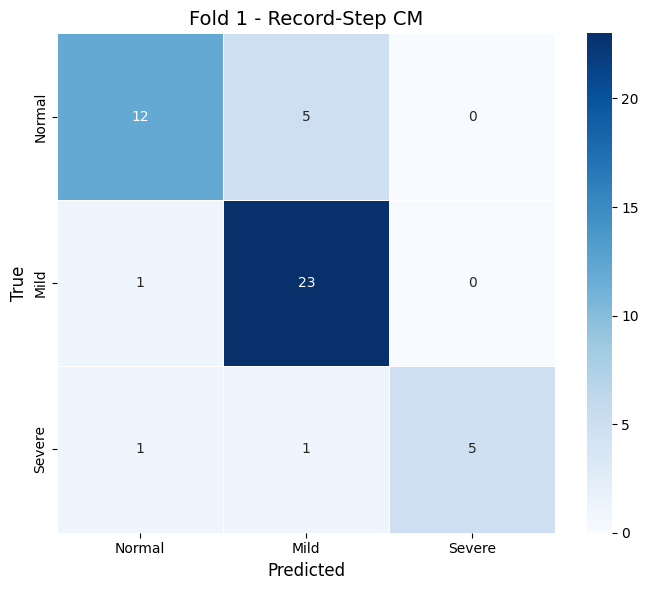


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.4289 - loss: 1.4139  val_record_step_balanced_accuracy: 0.5373
78/78 ━━━━━━━━━━━━━━━━━━━━ 36s 258ms/step - accuracy: 0.4211 - loss: 1.4446 - val_accuracy: 0.4551 - val_loss: 1.0023 - val_record_step_balanced_accuracy: 0.5373 - learning_rate: 0.0010
Epoch 2/100
76/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4637 - loss: 1.3150  val_record_step_balanced_accuracy: 0.4643
78/78 ━

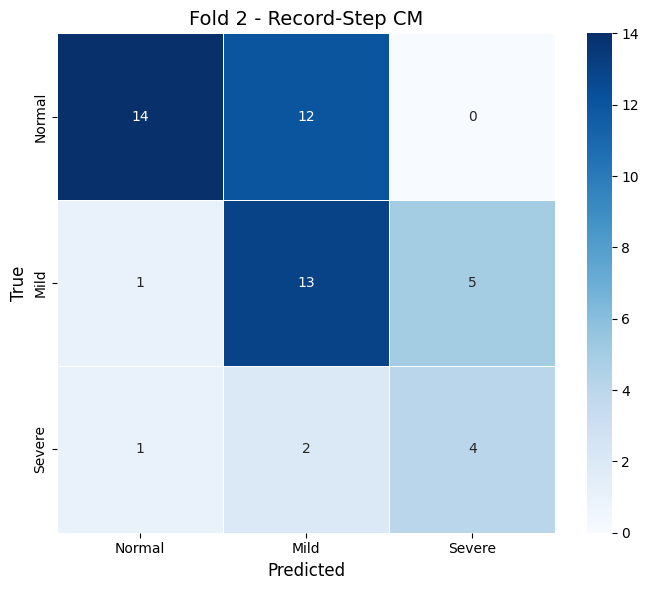


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4110 - loss: 1.4671  val_record_step_balanced_accuracy: 0.3739
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 248ms/step - accuracy: 0.4332 - loss: 1.4073 - val_accuracy: 0.4206 - val_loss: 1.0766 - val_record_step_balanced_accuracy: 0.3739 - learning_rate: 0.0010
Epoch 2/100
77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4869 - loss: 1.3362  val_record_step_balanced_accuracy: 0.4156
80/80 ━

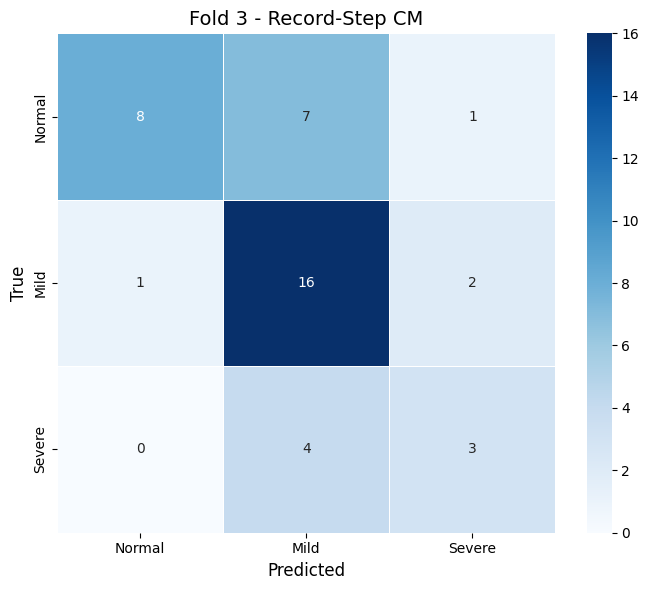


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4636 - loss: 1.3537  val_record_step_balanced_accuracy: 0.5169
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 251ms/step - accuracy: 0.4687 - loss: 1.3822 - val_accuracy: 0.4296 - val_loss: 1.0700 - val_record_step_balanced_accuracy: 0.5169 - learning_rate: 0.0010
Epoch 2/100
74/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4991 - loss: 1.2875  val_record_step_balanced_accuracy: 0.5472
79/79 ━

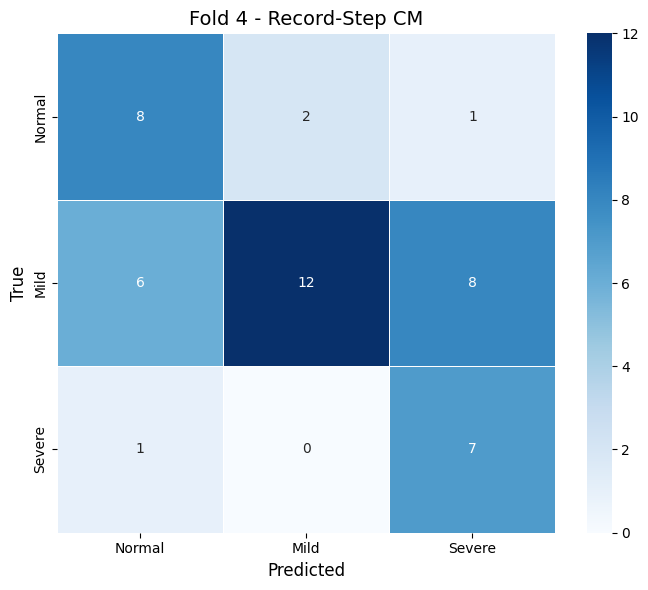


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.3884 - loss: 1.4681  val_record_step_balanced_accuracy: 0.5589
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 248ms/step - accuracy: 0.4371 - loss: 1.4015 - val_accuracy: 0.5397 - val_loss: 1.0022 - val_record_step_balanced_accuracy: 0.5589 - learning_rate: 0.0010
Epoch 2/100
72/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4651 - loss: 1.3478  val_record_step_balanced_accuracy: 0.5530
80/80 ━

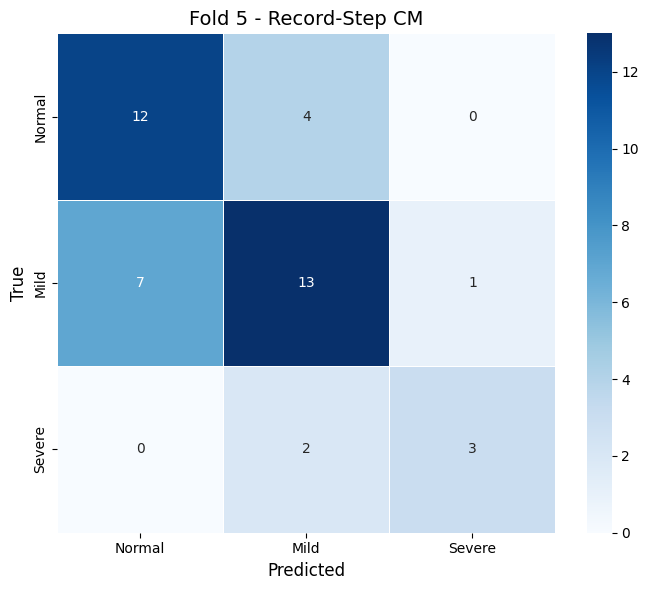


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
76/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3684 - loss: 1.5662  val_record_step_balanced_accuracy: 0.4167
78/78 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - accuracy: 0.3854 - loss: 1.4902 - val_accuracy: 0.4867 - val_loss: 1.0819 - val_record_step_balanced_accuracy: 0.4167 - learning_rate: 0.0010
Epoch 2/100
69/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5106 - loss: 1.3739  val_record_step_balanced_accuracy: 0.4611
78/78 ━━━

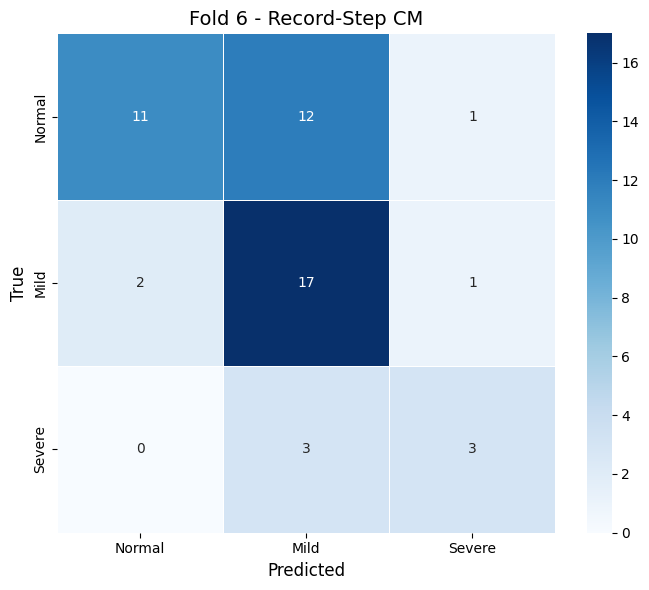


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.3998 - loss: 1.4220  val_record_step_balanced_accuracy: 0.4650
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 264ms/step - accuracy: 0.4421 - loss: 1.3778 - val_accuracy: 0.3913 - val_loss: 1.0802 - val_record_step_balanced_accuracy: 0.4650 - learning_rate: 0.0010
Epoch 2/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4699 - loss: 1.3571  val_record_step_balanced_accuracy: 0.4368
79/79 ━

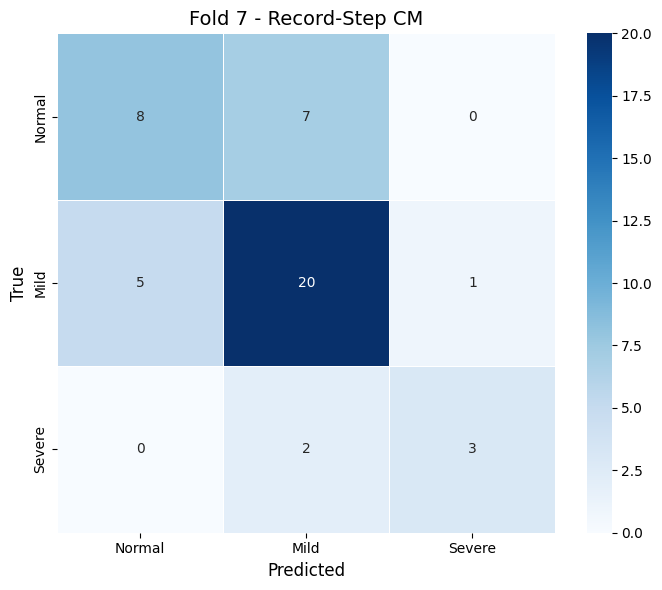


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4125 - loss: 1.4905  val_record_step_balanced_accuracy: 0.4842
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - accuracy: 0.4400 - loss: 1.4285 - val_accuracy: 0.4773 - val_loss: 1.0505 - val_record_step_balanced_accuracy: 0.4842 - learning_rate: 0.0010
Epoch 2/100
72/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4518 - loss: 1.3835  val_record_step_balanced_accuracy: 0.4741
80/80 ━

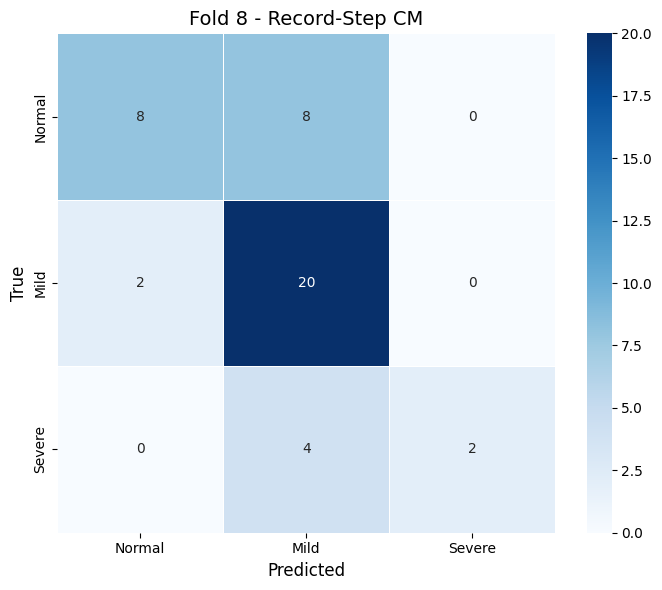


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3767 - loss: 1.4385  val_record_step_balanced_accuracy: 0.4763
78/78 ━━━━━━━━━━━━━━━━━━━━ 36s 256ms/step - accuracy: 0.4257 - loss: 1.4044 - val_accuracy: 0.4967 - val_loss: 1.0238 - val_record_step_balanced_accuracy: 0.4763 - learning_rate: 0.0010
Epoch 2/100
75/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4882 - loss: 1.3023  val_record_step_balanced_accuracy: 0.4757
78/78

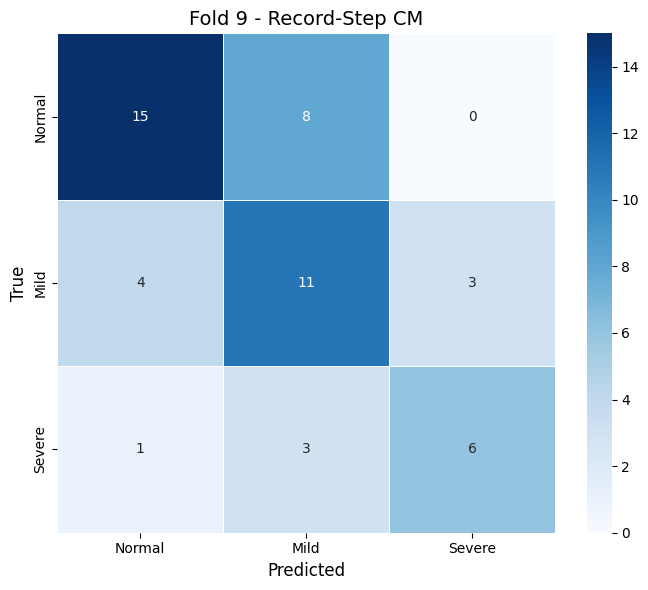


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3803 - loss: 1.4160  val_record_step_balanced_accuracy: 0.5402
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 269ms/step - accuracy: 0.4246 - loss: 1.4101 - val_accuracy: 0.5942 - val_loss: 0.9783 - val_record_step_balanced_accuracy: 0.5402 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4914 - loss: 1.3385  val_record_step_balanced_accuracy: 0.5402
79/79 

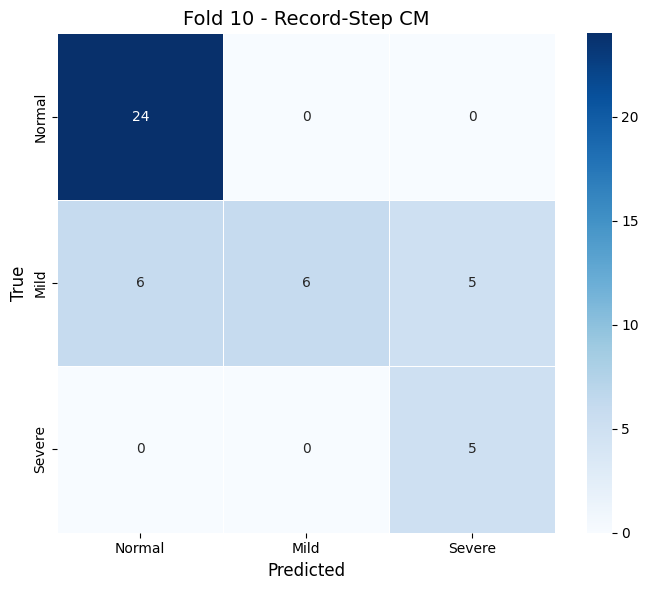


CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6703 +/- 0.0711
  balanced_accuracy     : 0.6549 +/- 0.0735
  macro_f1              : 0.6459 +/- 0.0688
  --------------------------------------------------
  precision_Normal  : 0.7597 +/- 0.1178
  recall_Normal  : 0.6365 +/- 0.1573
  f1_Normal  : 0.6750 +/- 0.0904
  precision_Mild    : 0.6754 +/- 0.1585
  recall_Mild    : 0.7058 +/- 0.1870
  f1_Mild    : 0.6572 +/- 0.0997
  precision_Severe  : 0.6649 +/- 0.1995
  recall_Severe  : 0.6223 +/- 0.1884
  f1_Severe  : 0.6055 +/- 0.1053

Overall Confusion Matrix (all folds combined):
[[120  65   3]
 [ 35 151  26]
 [  4  21  41]]

  All folds are reliable - no filtering needed.


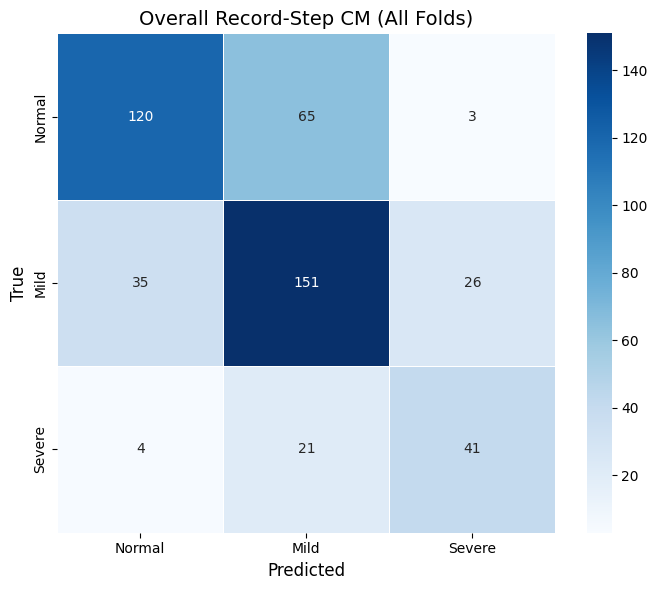

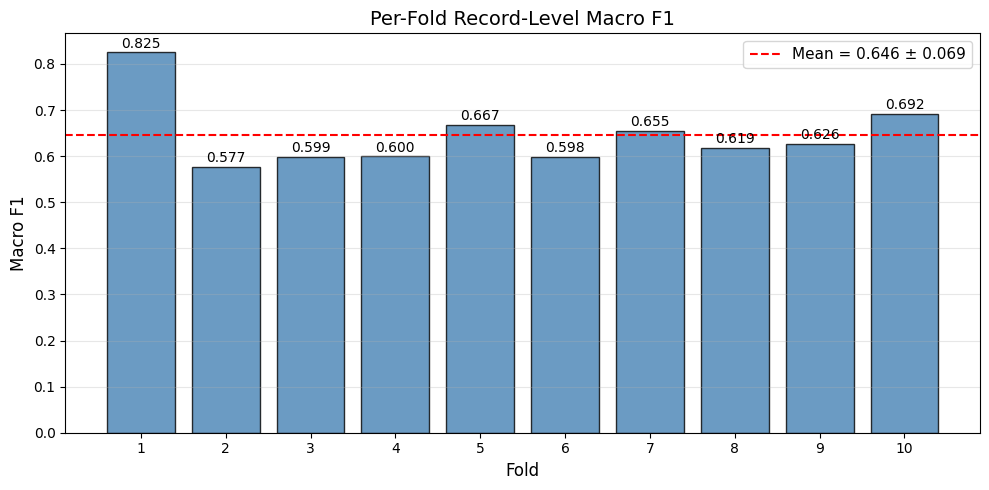

Manual weights: {0: 0.9, 1: 1.2, 2: 2.5}
Effective Severe threshold/fold: 5
Mean macro F1: 0.6459
Mean balanced accuracy: 0.6549
Mean Mild recall: 0.7058
Mean Severe recall: 0.6223

Run summary saved to outputs/step23_softmax_short_plan/step23_softmax_results.json


In [125]:
def _manual_class_weight_resolver_factory(manual_weights):
    def _resolver(y_train: np.ndarray) -> dict:
        if manual_weights is None:
            return _original_compute_class_weights_from_y(y_train)
        resolved = {
            int(class_idx): float(manual_weights.get(class_idx, 1.0))
            for class_idx in range(NUM_CLASSES)
        }
        print(f"  Class weights (manual override): {resolved}")
        return resolved
    return _resolver


try:
    print("\n" + "=" * 70)
    print("Running fixed class-weight experiment")
    print(f"Manual class weights: {manual_class_weights}")
    print("=" * 70)

    compute_class_weights_from_y = _manual_class_weight_resolver_factory(manual_class_weights)
    scratch_results = run_grouped_cv(
        X=X_all,
        y=y_all,
        groups=groups_all,
        metadata=meta_all,
        cfg=CFG,
        X_raw=X_all,
        feature_missing_frac=meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32),
    )
finally:
    compute_class_weights_from_y = _original_compute_class_weights_from_y

effective_min_severe_threshold = (
    scratch_results[0].get('effective_min_severe_threshold', CFG['min_severe_records'])
    if scratch_results else CFG['min_severe_records']
)

scratch_summary = {
    'experiment': 'fixed_class_weights',
    'steps': CFG['step_numbers'],
    'n_folds': CFG['n_splits'],
    'n_reliable_folds': len([result for result in scratch_results if result.get('is_reliable', True)]),
    'window_length': CFG['segment_length'],
    'max_nan_fraction': CFG['max_nan_fraction'],
    'n_windows': len(X_all),
    'n_records': int(len(np.unique(groups_all))),
    'n_record_steps': int(len(step_unit_table)),
    'manual_class_weights': manual_class_weights,
    'requested_min_severe_threshold': CFG['min_severe_records'],
    'effective_min_severe_threshold': effective_min_severe_threshold,
    'mean_macro_f1': float(np.mean([result['macro_f1'] for result in scratch_results])),
    'std_macro_f1': float(np.std([result['macro_f1'] for result in scratch_results])),
    'mean_balanced_acc': float(np.mean([result['balanced_accuracy'] for result in scratch_results])),
    'std_balanced_acc': float(np.std([result['balanced_accuracy'] for result in scratch_results])),
    'mean_accuracy': float(np.mean([result['accuracy'] for result in scratch_results])),
    'std_accuracy': float(np.std([result['accuracy'] for result in scratch_results])),
    'mean_recall_Normal': float(np.mean([result['recall_Normal'] for result in scratch_results])),
    'mean_recall_Mild': float(np.mean([result['recall_Mild'] for result in scratch_results])),
    'mean_recall_Severe': float(np.mean([result['recall_Severe'] for result in scratch_results])),
    'per_fold': [
        {key: value for key, value in result.items() if key != 'confusion_matrix'}
        for result in scratch_results
    ],
}

reliable_results = [result for result in scratch_results if result.get('is_reliable', True)]
if reliable_results:
    scratch_summary['reliable_mean_macro_f1'] = float(np.mean([result['macro_f1'] for result in reliable_results]))
    scratch_summary['reliable_std_macro_f1'] = float(np.std([result['macro_f1'] for result in reliable_results]))
    scratch_summary['reliable_mean_balanced_acc'] = float(np.mean([result['balanced_accuracy'] for result in reliable_results]))
    scratch_summary['reliable_std_balanced_acc'] = float(np.std([result['balanced_accuracy'] for result in reliable_results]))

with open(OUTPUT_DIR / "step23_softmax_results.json", 'w') as summary_file:
    json.dump(scratch_summary, summary_file, indent=2, default=str)

print(f"Manual weights: {manual_class_weights}")
print(f"Effective Severe threshold/fold: {effective_min_severe_threshold}")
print(f"Mean macro F1: {scratch_summary['mean_macro_f1']:.4f}")
print(f"Mean balanced accuracy: {scratch_summary['mean_balanced_acc']:.4f}")
print(f"Mean Mild recall: {scratch_summary['mean_recall_Mild']:.4f}")
print(f"Mean Severe recall: {scratch_summary['mean_recall_Severe']:.4f}")
print(f"\nRun summary saved to {OUTPUT_DIR / 'step23_softmax_results.json'}")

In [126]:
#Final summary
def _fmt(values):
    return f"{np.mean(values):.4f} +/- {np.std(values):.4f}"
print("Final Summary")

if 'scratch_results' not in globals() or 'scratch_summary' not in globals():
    raise RuntimeError("Run the experiment cell first to execute the fixed class-weight experiment.")

requested_threshold = scratch_summary.get('requested_min_severe_threshold', CFG['min_severe_records'])
effective_threshold = scratch_summary.get('effective_min_severe_threshold', requested_threshold)

print(f"\nExperiment: {scratch_summary['experiment']}")
print(f"Manual weights: {scratch_summary.get('manual_class_weights')}")

print(f"\nExperiment scope:")
print(f"Steps used: {CFG['step_numbers']}")
print(f"Window length: {CFG['segment_length']} samples ({CFG['segment_minutes']} min)")
print(f"Max NaN fraction: {CFG['max_nan_fraction']:.0%}")
print(f"Grouped CV by rec_id: yes")
print(f"Evaluation unit: record-step")
print(f"Feature branch: compact engineered FHR features")
print(f"Requested Severe threshold:{requested_threshold}")
print(f"Effective Severe threshold:{effective_threshold}")

print(f"\nPer-fold reliability (effective min Severe step-units = {effective_threshold}):")
print(f"  {'Fold':<8} {'Macro F1':>12} {'Reliable?':>12}  {'Severe step-units':>18}")

for index in range(CFG['n_splits']):
    fold = scratch_results[index]
    reliable_label = "Yes" if fold.get('is_reliable', True) else "No"
    severe_count = fold.get('n_severe_val_step_units', '?')
    print(f"  Fold {index + 1:<3} {fold['macro_f1']:>12.4f} {reliable_label:>12}  {severe_count:>18}")

print(f"\nRecord-step metrics across all folds:")
for metric_name in ['accuracy', 'balanced_accuracy', 'macro_f1']:
    metric_values = [fold[metric_name] for fold in scratch_results]
    print(f"  {metric_name:<22} {_fmt(metric_values)}")

print("\nPer-class recall:")
for class_name in CLASS_NAMES:
    metric_values = [fold[f'recall_{class_name}'] for fold in scratch_results]
    print(f"  {class_name:<22} {_fmt(metric_values)}")

print("\nPer-class F1:")
for class_name in CLASS_NAMES:
    metric_values = [fold[f'f1_{class_name}'] for fold in scratch_results]
    print(f"  {class_name:<22} {_fmt(metric_values)}")

reliable_folds = [fold for fold in scratch_results if fold.get('is_reliable', True)]
if 0 < len(reliable_folds) < CFG['n_splits']:
    print(f"\nReliable folds only ({len(reliable_folds)}/{CFG['n_splits']}):")
    for metric_name in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        metric_values = [fold[metric_name] for fold in reliable_folds]
        print(f"  {metric_name:<22} {_fmt(metric_values)}")
elif len(reliable_folds) == CFG['n_splits']:
    print("\nAll folds met the validation reliability threshold.")

print("Results saved to", OUTPUT_DIR)

Final Summary

Experiment: fixed_class_weights
Manual weights: {0: 0.9, 1: 1.2, 2: 2.5}

Experiment scope:
Steps used: [2, 3]
Window length: 1800 samples (30 min)
Max NaN fraction: 16%
Grouped CV by rec_id: yes
Evaluation unit: record-step
Feature branch: compact engineered FHR features
Requested Severe threshold:10
Effective Severe threshold:5

Per-fold reliability (effective min Severe step-units = 5):
  Fold         Macro F1    Reliable?   Severe step-units
  Fold 1         0.8252          Yes                   7
  Fold 2         0.5773          Yes                   7
  Fold 3         0.5991          Yes                   7
  Fold 4         0.5996          Yes                   8
  Fold 5         0.6675          Yes                   5
  Fold 6         0.5980          Yes                   6
  Fold 7         0.6551          Yes                   5
  Fold 8         0.6187          Yes                   6
  Fold 9         0.6264          Yes                  10
  Fold 10        0.692

## 13a. Hybrid CNN Training Diagnostics

Overfitting checks: train vs val loss, train vs val accuracy, early stopping epoch, and train–val gap analysis across all folds.

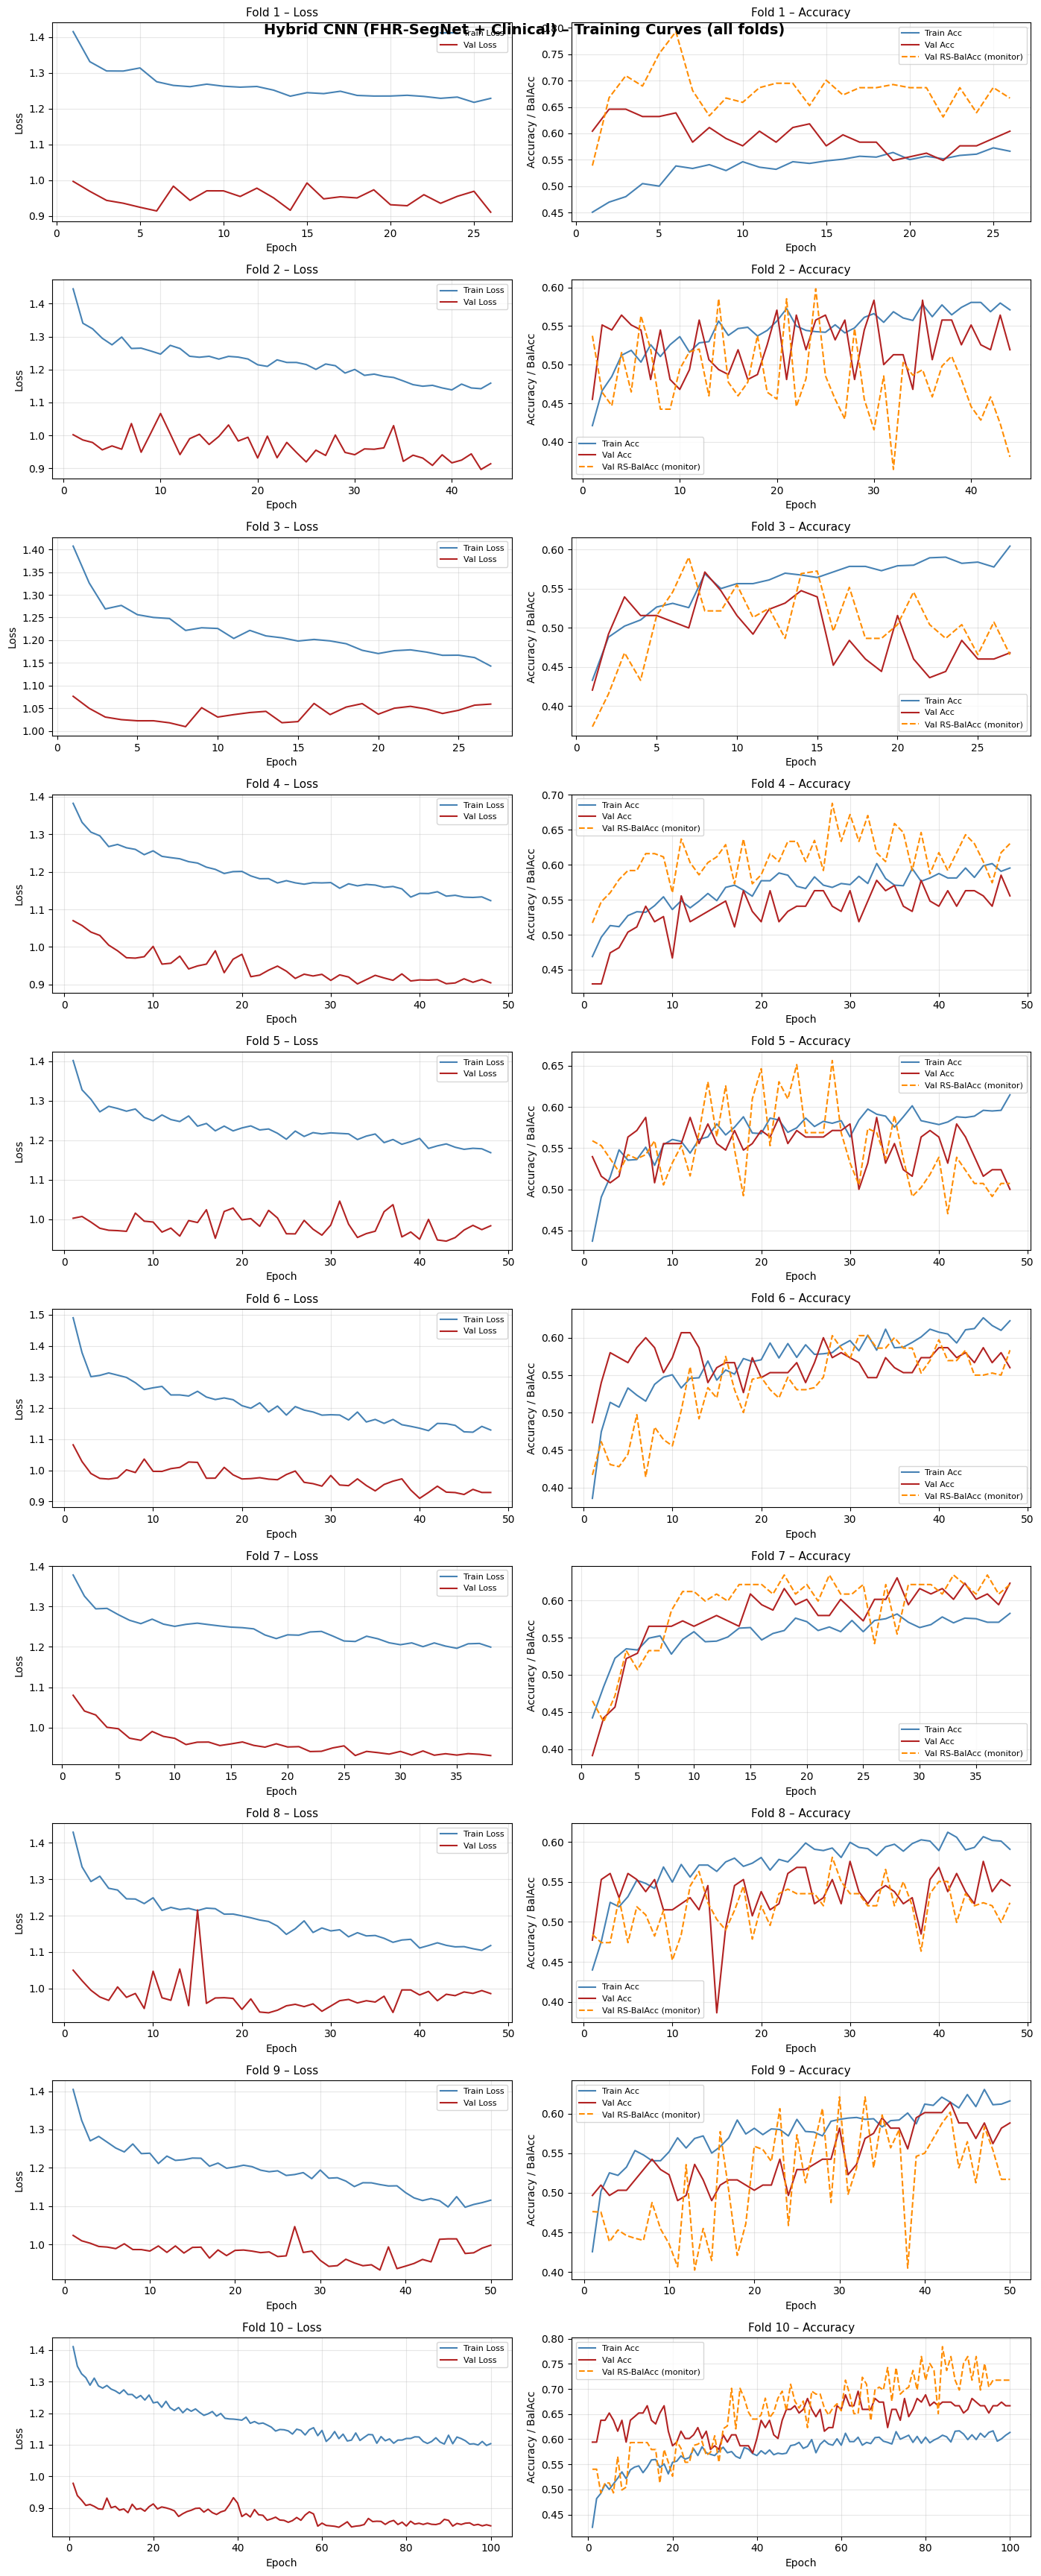

In [127]:
# Hybrid CNN: Train vs Val Loss & Accuracy per fold
def plot_training_curves(fold_results, model_name, save_prefix=None):
    """Plot train/val loss and accuracy curves for all folds side-by-side."""
    histories = [r['history'] for r in fold_results if 'history' in r]
    if not histories:
        print(f"No training history found for {model_name}. Re-run training cells first.")
        return

    n_folds = len(histories)
    fig, axes = plt.subplots(n_folds, 2, figsize=(14, 3.5 * n_folds), squeeze=False)

    for i, hist in enumerate(histories):
        epochs = range(1, len(hist['loss']) + 1)

        # Loss
        ax = axes[i, 0]
        ax.plot(epochs, hist['loss'], label='Train Loss', color='steelblue')
        ax.plot(epochs, hist['val_loss'], label='Val Loss', color='firebrick')
        ax.set_title(f'Fold {i+1} – Loss', fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Accuracy
        ax = axes[i, 1]
        ax.plot(epochs, hist['accuracy'], label='Train Acc', color='steelblue')
        ax.plot(epochs, hist['val_accuracy'], label='Val Acc', color='firebrick')
        if 'val_record_step_balanced_accuracy' in hist:
            ax.plot(epochs, hist['val_record_step_balanced_accuracy'],
                    label='Val RS-BalAcc (monitor)', color='darkorange', linestyle='--')
        ax.set_title(f'Fold {i+1} – Accuracy', fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy / BalAcc')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(f'{model_name} – Training Curves (all folds)', fontsize=14, fontweight='bold')
    fig.tight_layout()
    if save_prefix:
        fig.savefig(OUTPUT_DIR / f'{save_prefix}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(scratch_results, 'Hybrid CNN (FHR-SegNet + Clinical)', save_prefix='hybrid_cnn')

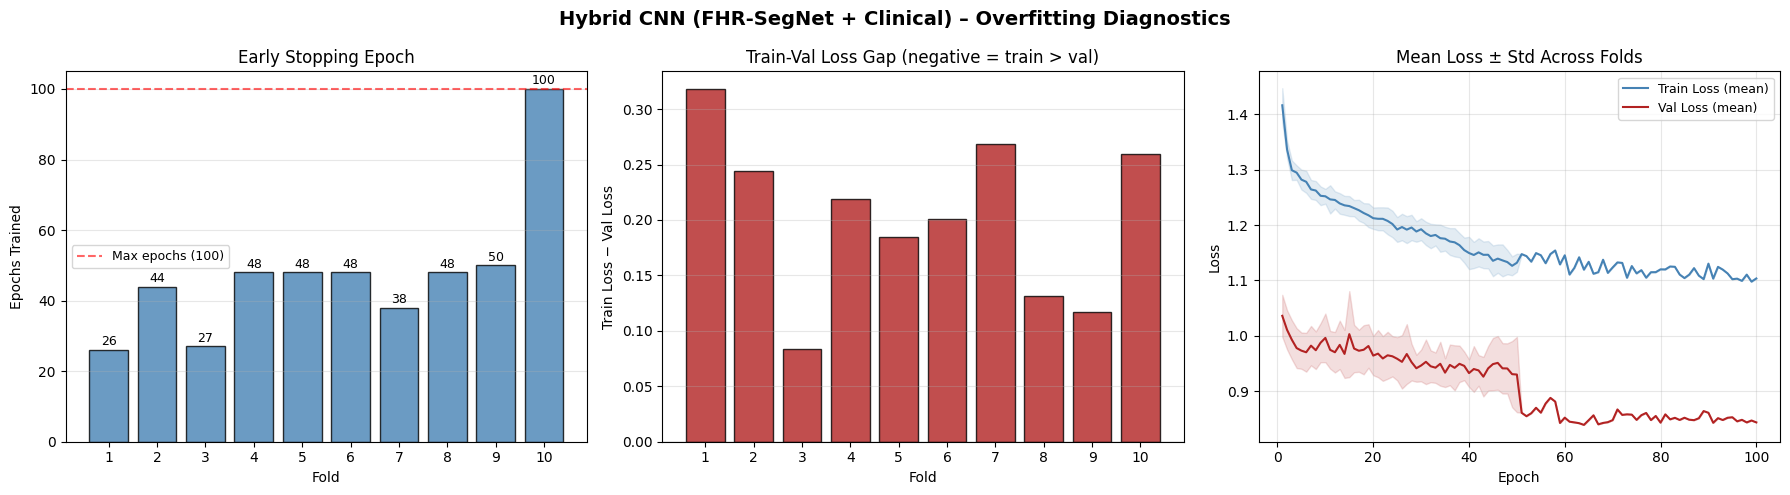

In [128]:
# Hybrid CNN: Early Stopping Epoch + Train-Val Gap Analysis
def plot_overfitting_summary(fold_results, model_name, max_epochs=None, save_prefix=None):
    """
    Two diagnostic plots:
    1. Bar chart of the epoch where training stopped per fold
    2. Final train-val loss gap per fold (positive = potential overfitting)
    """
    histories = [r['history'] for r in fold_results if 'history' in r]
    if not histories:
        print(f"No training history found for {model_name}.")
        return

    n_folds = len(histories)
    stop_epochs = [len(h['loss']) for h in histories]
    loss_gaps = [h['loss'][-1] - h['val_loss'][-1] for h in histories]
    # Negative gap = train loss < val loss = expected; large positive gap = val << train = overfitting

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1 – Early stopping epoch
    ax = axes[0]
    folds = range(1, n_folds + 1)
    bars = ax.bar(folds, stop_epochs, color='steelblue', edgecolor='black', alpha=0.8)
    if max_epochs:
        ax.axhline(max_epochs, linestyle='--', color='red', alpha=0.6, label=f'Max epochs ({max_epochs})')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Epochs Trained')
    ax.set_title('Early Stopping Epoch', fontsize=12)
    ax.set_xticks(list(folds))
    for bar, ep in zip(bars, stop_epochs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(ep), ha='center', va='bottom', fontsize=9)
    if max_epochs:
        ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 2 – Train-Val loss gap
    ax = axes[1]
    colors = ['firebrick' if g > 0 else 'seagreen' for g in loss_gaps]
    ax.bar(folds, loss_gaps, color=colors, edgecolor='black', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Train Loss − Val Loss')
    ax.set_title('Train-Val Loss Gap (negative = train > val)', fontsize=12)
    ax.set_xticks(list(folds))
    ax.grid(axis='y', alpha=0.3)

    # 3 – Mean loss curves across folds
    ax = axes[2]
    max_ep = max(len(h['loss']) for h in histories)
    train_matrix = np.full((n_folds, max_ep), np.nan)
    val_matrix = np.full((n_folds, max_ep), np.nan)
    for i, h in enumerate(histories):
        ep = len(h['loss'])
        train_matrix[i, :ep] = h['loss']
        val_matrix[i, :ep] = h['val_loss']

    epochs = np.arange(1, max_ep + 1)
    train_mean = np.nanmean(train_matrix, axis=0)
    val_mean = np.nanmean(val_matrix, axis=0)
    train_std = np.nanstd(train_matrix, axis=0)
    val_std = np.nanstd(val_matrix, axis=0)

    ax.plot(epochs, train_mean, color='steelblue', label='Train Loss (mean)')
    ax.fill_between(epochs, train_mean - train_std, train_mean + train_std,
                     color='steelblue', alpha=0.15)
    ax.plot(epochs, val_mean, color='firebrick', label='Val Loss (mean)')
    ax.fill_between(epochs, val_mean - val_std, val_mean + val_std,
                     color='firebrick', alpha=0.15)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Mean Loss ± Std Across Folds', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    fig.suptitle(f'{model_name} – Overfitting Diagnostics', fontsize=14, fontweight='bold')
    fig.tight_layout()
    if save_prefix:
        fig.savefig(OUTPUT_DIR / f'{save_prefix}_overfitting_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_summary(
    scratch_results, 'Hybrid CNN (FHR-SegNet + Clinical)',
    max_epochs=CFG['scratch_epochs'],
    save_prefix='hybrid_cnn',
)

# 14. Model Comparison: Baseline + ResNet1D

Compare the hybrid CNN against classical ML baselines (Logistic Regression, SVM, Random Forest)
and a ResNet1D architecture. All models use the **same folds, same data, same evaluation pipeline**
for a fair comparison.

In [129]:
# Additional imports for baselines
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from scipy.stats import loguniform, uniform
import itertools

In [55]:
# Compute shared baseline folds and clinical features at notebook scope
baseline_folds, _baseline_effective_min = stratified_record_kfold_with_constraint(
    meta_all,
    n_splits=CFG['n_splits'],
    min_severe_records=CFG.get('min_severe_records', 10),
    max_attempts=CFG.get('max_cv_attempts', 100),
    cv_seed=CFG['cv_seed'],
)

clin_all = compute_all_engineered_features(
    X_all,
    fs=SAMPLING_RATE,
    missing_frac_prefill=meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32),
)

print(f"Baseline folds: {len(baseline_folds)} folds (effective min Severe = {_baseline_effective_min})")
print(f"Clinical features: shape {clin_all.shape}")

  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Baseline folds: 10 folds (effective min Severe = 5)
Clinical features: shape (1398, 10)


In [56]:
def summarise_fold_results(fold_results, model_name):
    """Summarise a list of per-fold metric dicts into a single row."""
    summary = {'model': model_name}
    for key in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        vals = [f[key] for f in fold_results]
        summary[f'{key}_mean'] = float(np.mean(vals))
        summary[f'{key}_std'] = float(np.std(vals))
    for cls in CLASS_NAMES:
        recall_vals = [f[f'recall_{cls}'] for f in fold_results]
        summary[f'{cls.lower()}_recall_mean'] = float(np.mean(recall_vals))
        summary[f'{cls.lower()}_recall_std'] = float(np.std(recall_vals))
    return summary

In [57]:
def make_group_aware_inner_splitter(n_splits: int = 3, random_state: int = GLOBAL_SEED):
    if HAS_STRATIFIED_GROUP_KFOLD:
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return GroupKFold(n_splits=n_splits)

In [58]:
def evaluate_sklearn_baseline(
    model_class,
    model_kwargs: dict,
    X_features: np.ndarray,
    y: np.ndarray,
    metadata: pd.DataFrame,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    model_name: str = 'Baseline',
    scale_features: bool = True,
    param_distributions=None,
    n_search_iter: int = 30,
    inner_cv: int = 3,
) -> List[dict]:
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    fold_results = []
    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f'  {model_name} -- Fold {fold_idx + 1}/{len(folds)}')
        X_tr = X_features[train_idx]
        X_va = X_features[val_idx]
        y_tr = y[train_idx]
        y_va = y[val_idx]
        meta_tr = meta.iloc[train_idx].reset_index(drop=True)
        meta_val = meta.iloc[val_idx].reset_index(drop=True)
        groups_tr = meta_tr['rec_id'].astype(str).to_numpy()
        if scale_features:
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)
        if param_distributions is not None:
            inner_splitter = make_group_aware_inner_splitter(
                n_splits=inner_cv, random_state=GLOBAL_SEED + fold_idx,
            )
            search = RandomizedSearchCV(
                estimator=model_class(**model_kwargs),
                param_distributions=param_distributions,
                n_iter=n_search_iter,
                cv=inner_splitter,
                scoring='f1_macro',
                random_state=GLOBAL_SEED,
                n_jobs=-1,
                refit=True,
            )
            search.fit(X_tr, y_tr, groups=groups_tr)
            clf = search.best_estimator_
            print(f'    Best params: {search.best_params_}  (inner F1={search.best_score_:.4f})')
        else:
            clf = model_class(**model_kwargs)
            clf.fit(X_tr, y_tr)
        y_proba_val = clf.predict_proba(X_va)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        fold_results.append(metrics)
        print(
            f'    Acc={metrics["accuracy"]:.4f}  BalAcc={metrics["balanced_accuracy"]:.4f}  '
            f'F1={metrics["macro_f1"]:.4f}  '
            f'R_N={metrics["recall_Normal"]:.3f}  R_M={metrics["recall_Mild"]:.3f}  R_S={metrics["recall_Severe"]:.3f}'
        )
    return fold_results

In [59]:
# Logistic Regression baseline
lr_param_dist = [
    {'C': loguniform(1e-3, 1e3), 'penalty': ['l2'], 'solver': ['lbfgs', 'saga']},
    {'C': loguniform(1e-3, 1e3), 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': uniform(0.1, 0.8)},
]

lr_results = evaluate_sklearn_baseline(
    model_class=LogisticRegression,
    model_kwargs=dict(multi_class='multinomial', max_iter=3000, class_weight='balanced', random_state=GLOBAL_SEED),
    X_features=clin_all,
    y=y_all,
    metadata=meta_all,
    folds=baseline_folds,
    model_name='Logistic Regression',
    scale_features=True,
    param_distributions=lr_param_dist,
    n_search_iter=25,
    inner_cv=3,
)
lr_summary = summarise_fold_results(lr_results, 'Logistic Regression')
print(f'\nLR -- Macro F1: {lr_summary["macro_f1_mean"]:.4f} +/- {lr_summary["macro_f1_std"]:.4f}')

  Logistic Regression -- Fold 1/10
    Best params: {'C': np.float64(47.6591180868084), 'penalty': 'l2', 'solver': 'lbfgs'}  (inner F1=0.4539)
    Acc=0.5417  BalAcc=0.6264  F1=0.5452  R_N=0.647  R_M=0.375  R_S=0.857
  Logistic Regression -- Fold 2/10
    Best params: {'C': np.float64(2.5480149212968444), 'l1_ratio': np.float64(0.12505063396444688), 'penalty': 'elasticnet', 'solver': 'saga'}  (inner F1=0.4583)
    Acc=0.5962  BalAcc=0.5744  F1=0.5528  R_N=0.731  R_M=0.421  R_S=0.571
  Logistic Regression -- Fold 3/10
    Best params: {'C': np.float64(0.07417652034871831), 'l1_ratio': np.float64(0.5160544169422486), 'penalty': 'elasticnet', 'solver': 'saga'}  (inner F1=0.4676)
    Acc=0.4286  BalAcc=0.4323  F1=0.4125  R_N=0.500  R_M=0.368  R_S=0.429
  Logistic Regression -- Fold 4/10
    Best params: {'C': np.float64(0.5694995061301531), 'penalty': 'l2', 'solver': 'lbfgs'}  (inner F1=0.4575)
    Acc=0.4889  BalAcc=0.6125  F1=0.4908  R_N=0.818  R_M=0.269  R_S=0.750
  Logistic Regression 

In [60]:
# SVM baseline
svm_param_dist = {
    'C': loguniform(1e-2, 1e3),
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 1e-4, 1e-3, 1e-2, 1e-1, 1],
    'degree': [2, 3],
}

svm_results = evaluate_sklearn_baseline(
    model_class=SVC,
    model_kwargs=dict(probability=True, class_weight='balanced', random_state=GLOBAL_SEED),
    X_features=clin_all,
    y=y_all,
    metadata=meta_all,
    folds=baseline_folds,
    model_name='SVM',
    scale_features=True,
    param_distributions=svm_param_dist,
    n_search_iter=50,
    inner_cv=3,
)
svm_summary = summarise_fold_results(svm_results, 'SVM')
print(f'\nSVM -- Macro F1: {svm_summary["macro_f1_mean"]:.4f} +/- {svm_summary["macro_f1_std"]:.4f}')

  SVM -- Fold 1/10
    Best params: {'C': np.float64(0.22943583326123324), 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}  (inner F1=0.4987)
    Acc=0.5625  BalAcc=0.4208  F1=0.3904  R_N=0.471  R_M=0.792  R_S=0.000
  SVM -- Fold 2/10
    Best params: {'C': np.float64(0.22943583326123324), 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}  (inner F1=0.5051)
    Acc=0.6154  BalAcc=0.4764  F1=0.4435  R_N=0.692  R_M=0.737  R_S=0.000
  SVM -- Fold 3/10
    Best params: {'C': np.float64(0.22737628102536853), 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}  (inner F1=0.5120)
    Acc=0.5952  BalAcc=0.4649  F1=0.4274  R_N=0.500  R_M=0.895  R_S=0.000
  SVM -- Fold 4/10
    Best params: {'C': np.float64(0.22943583326123324), 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}  (inner F1=0.5040)
    Acc=0.6444  BalAcc=0.5580  F1=0.5246  R_N=0.818  R_M=0.731  R_S=0.125
  SVM -- Fold 5/10
    Best params: {'C': np.float64(0.22943583326123324), 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}  (inner F1=0.5062)
    Acc=0.5

In [61]:
# Random Forest baseline
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [None, 10, 20, 30, 50, 70],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.5],
}

rf_results = evaluate_sklearn_baseline(
    model_class=RandomForestClassifier,
    model_kwargs=dict(class_weight='balanced_subsample', random_state=GLOBAL_SEED, n_jobs=-1),
    X_features=clin_all,
    y=y_all,
    metadata=meta_all,
    folds=baseline_folds,
    model_name='Random Forest',
    scale_features=False,
    param_distributions=rf_param_dist,
    n_search_iter=60,
    inner_cv=3,
)
rf_summary = summarise_fold_results(rf_results, 'Random Forest')
print(f'\nRF -- Macro F1: {rf_summary["macro_f1_mean"]:.4f} +/- {rf_summary["macro_f1_std"]:.4f}')

  Random Forest -- Fold 1/10
    Best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 20}  (inner F1=0.4761)
    Acc=0.5417  BalAcc=0.4743  F1=0.5073  R_N=0.471  R_M=0.667  R_S=0.286
  Random Forest -- Fold 2/10
    Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30}  (inner F1=0.5170)
    Acc=0.5962  BalAcc=0.5538  F1=0.5529  R_N=0.654  R_M=0.579  R_S=0.429
  Random Forest -- Fold 3/10
    Best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}  (inner F1=0.5029)
    Acc=0.5238  BalAcc=0.4156  F1=0.4069  R_N=0.562  R_M=0.684  R_S=0.000
  Random Forest -- Fold 4/10
    Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}  (inner F1=0.5107)
    Acc=0.6667  BalAcc=0.6573  F1=0.6300  R_N=0.818  R_M=0.654  R_S=0.500
 

# ResNet Model

In [130]:
# Fixed class weights for deep model baselines (same as hybrid CNN)
FIXED_CLASS_WEIGHT = {
    0: 0.9,   # Normal
    1: 1.2,   # Mild
    2: 2.5,   # Severe
}

In [131]:
def build_resnet1d(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = NUM_CLASSES,
    dropout_rate: float = 0.40,
    kernel_size: int = 7,
    base_filters: int = 64,
    n_clinical_features: int = 0,
) -> Model:
    """1D ResNet baseline for FHR classification."""

    def _res_block(x, filters, kernel, dilation=1, name="res"):
        shortcut = x
        y = Conv1D(filters, kernel, padding='same', dilation_rate=dilation,
                   use_bias=False, name=f'{name}_conv1')(x)
        y = BatchNormalization(name=f'{name}_bn1')(y)
        y = Activation('relu', name=f'{name}_relu1')(y)
        y = Conv1D(filters, kernel, padding='same', dilation_rate=dilation,
                   use_bias=False, name=f'{name}_conv2')(y)
        y = BatchNormalization(name=f'{name}_bn2')(y)
        if shortcut.shape[-1] != filters:
            shortcut = Conv1D(filters, 1, padding='same', use_bias=False,
                              name=f'{name}_proj')(shortcut)
            shortcut = BatchNormalization(name=f'{name}_proj_bn')(shortcut)
        y = Add(name=f'{name}_add')([shortcut, y])
        y = Activation('relu', name=f'{name}_relu2')(y)
        return y

    fhr_input = Input(shape=(input_length, 1), name='fhr_input')
    x = Conv1D(base_filters, kernel_size, padding='same', use_bias=False, name='stem_conv')(fhr_input)
    x = BatchNormalization(name='stem_bn')(x)
    x = Activation('relu', name='stem_relu')(x)
    x = AveragePooling1D(4, name='stem_pool')(x)

    x = _res_block(x, base_filters, kernel_size, name='res1')
    x = Dropout(dropout_rate, name='drop1')(x)
    x = AveragePooling1D(2, name='pool1')(x)

    x = _res_block(x, base_filters * 2, kernel_size, name='res2')
    x = Dropout(dropout_rate, name='drop2')(x)
    x = AveragePooling1D(2, name='pool2')(x)

    x = _res_block(x, base_filters * 2, kernel_size, dilation=2, name='res3')
    x = Dropout(dropout_rate, name='drop3')(x)

    x = GlobalAveragePooling1D(name='gap')(x)

    if n_clinical_features > 0:
        clin_input = Input(shape=(n_clinical_features,), name='clinical_input')
        c = Dense(16, activation='elu', name='clinical_fc')(clin_input)
        c = Dropout(0.2, name='clinical_drop')(c)
        x = Concatenate(name='merge_clin')([x, c])
        x = Dense(32, activation='elu', name='fusion_fc')(x)
        x = Dropout(dropout_rate, name='fusion_drop')(x)
        output = Dense(num_classes, activation='softmax', name='output')(x)
        return Model(inputs=[fhr_input, clin_input], outputs=output, name='ResNet1D-ClinFeat')

    output = Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inputs=fhr_input, outputs=output, name='ResNet1D')

In [132]:
def fit_model_with_batch_backoff(
    model_builder,
    compile_kwargs: dict,
    fit_kwargs: dict,
    initial_batch_size: int,
    min_batch_size: int = 1,
) -> Tuple[Model, object, int]:
    """Train a model, retrying with smaller batches if TensorFlow runs out of memory."""
    batch_size = max(int(initial_batch_size), int(min_batch_size))
    last_error = None

    while batch_size >= min_batch_size:
        tf.keras.backend.clear_session()
        gc.collect()

        model = model_builder()
        model.compile(**compile_kwargs)

        try:
            history = model.fit(batch_size=batch_size, **fit_kwargs)
            return model, history, batch_size

        except tf.errors.ResourceExhaustedError as exc:
            last_error = exc
            print(f"      OOM at batch_size={batch_size}; retrying with a smaller batch.")

            del model
            tf.keras.backend.clear_session()
            gc.collect()

            if batch_size == min_batch_size:
                break

            next_batch_size = max(min_batch_size, batch_size // 2)
            if next_batch_size == batch_size:
                next_batch_size = batch_size - 1
            batch_size = next_batch_size

    raise last_error

In [133]:
def evaluate_resnet_config(
    cfg_hp: dict,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    model_name: str = "ResNet1D tuning",
) -> dict:
    """Evaluate one ResNet config across grouped tuning folds using fixed class weights."""
    meta = _ensure_step_keys(meta_all.reset_index(drop=True))
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n    {model_name} - tuning fold {fold_idx + 1}/{len(folds)}")

        X_tr = X_all[train_idx]
        X_va = X_all[val_idx]
        y_tr = y_all[train_idx]
        y_va = y_all[val_idx]
        meta_val = meta.iloc[val_idx].reset_index(drop=True)

        norm_stats = compute_norm_stats(X_tr)
        X_tr_n = apply_norm(X_tr, norm_stats)
        X_va_n = apply_norm(X_va, norm_stats)

        if CFG.get('augment_train', True):
            X_tr_n = augment_signal(X_tr_n, CFG)

        class_weight = FIXED_CLASS_WEIGHT.copy()

        y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
        y_va_cat = to_categorical(y_va, NUM_CLASSES)

        model_builder = lambda: build_resnet1d(
            dropout_rate=float(cfg_hp['dropout_rate']),
            kernel_size=int(cfg_hp['kernel_size']),
            base_filters=64,
        )

        compile_kwargs = dict(
            optimizer=Adam(learning_rate=float(cfg_hp['lr'])),
            loss=tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=CFG.get('label_smoothing', 0.05)
            ),
            metrics=['accuracy'],
        )

        rs_cb = RecordStepBalancedAccuracy(
            X_val=X_va_n,
            val_metadata=meta_val,
            batch_size=32,
        )

        cbs = get_callbacks(
            patience=CFG['scratch_patience'],
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            prefix_callbacks=[rs_cb],
            save_weights_only=True,
        )

        fit_kwargs = dict(
            x=X_tr_n,
            y=y_tr_cat,
            validation_data=(X_va_n, y_va_cat),
            epochs=CFG['scratch_epochs'],
            class_weight=class_weight,
            callbacks=cbs,
            verbose=0,
        )

        try:
            model, _, used_batch_size = fit_model_with_batch_backoff(
                model_builder=model_builder,
                compile_kwargs=compile_kwargs,
                fit_kwargs=fit_kwargs,
                initial_batch_size=int(CFG['scratch_batch']),
            )
        except tf.errors.ResourceExhaustedError:
            print(f"      OOM persisted for fold {fold_idx + 1}; marking this config as failed.")
            return {
                **cfg_hp,
                'macro_f1_mean': float('-inf'),
                'macro_f1_std': float('nan'),
                'balanced_accuracy_mean': float('-inf'),
                'balanced_accuracy_std': float('nan'),
                'status': 'oom',
                'failed_fold': fold_idx + 1,
            }

        y_proba = model.predict(X_va_n, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        fold_scores.append(metrics)

        print(
            f"      batch={used_batch_size}  "
            f"BalAcc={metrics['balanced_accuracy']:.4f}  "
            f"F1={metrics['macro_f1']:.4f}"
        )

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    macro_f1_vals = [m['macro_f1'] for m in fold_scores]
    bal_acc_vals = [m['balanced_accuracy'] for m in fold_scores]

    return {
        **cfg_hp,
        'macro_f1_mean': float(np.mean(macro_f1_vals)),
        'macro_f1_std': float(np.std(macro_f1_vals)),
        'balanced_accuracy_mean': float(np.mean(bal_acc_vals)),
        'balanced_accuracy_std': float(np.std(bal_acc_vals)),
        'status': 'ok',
    }

In [134]:
def evaluate_resnet_outer_folds(
    build_fn,
    X_signals: np.ndarray,
    y: np.ndarray,
    metadata: pd.DataFrame,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    model_name: str = "ResNet1D",
    epochs: int = 100,
    batch_size: int = 16,
    patience: int = 20,
    lr: float = 1e-3,
    augment: bool = True,
    label_smoothing: float = 0.05,
) -> List[dict]:
    """Evaluate a ResNet baseline fold-by-fold with fixed class weights."""
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n  {model_name} - Fold {fold_idx + 1}/{len(folds)}")

        X_tr = X_signals[train_idx]
        X_va = X_signals[val_idx]
        y_tr = y[train_idx]
        y_va = y[val_idx]
        meta_val = meta.iloc[val_idx].reset_index(drop=True)

        norm_stats = compute_norm_stats(X_tr)
        X_tr_n = apply_norm(X_tr, norm_stats)
        X_va_n = apply_norm(X_va, norm_stats)

        if augment:
            X_tr_n = augment_signal(X_tr_n, CFG)

        class_weight = FIXED_CLASS_WEIGHT.copy()

        y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
        y_va_cat = to_categorical(y_va, NUM_CLASSES)

        compile_kwargs = dict(
            optimizer=Adam(learning_rate=lr),
            loss=tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=label_smoothing
            ),
            metrics=['accuracy'],
        )

        rs_callback = RecordStepBalancedAccuracy(
            X_val=X_va_n,
            val_metadata=meta_val,
            batch_size=32,
        )

        callbacks = get_callbacks(
            patience=patience,
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            prefix_callbacks=[rs_callback],
            save_weights_only=True,
        )

        fit_kwargs = dict(
            x=X_tr_n,
            y=y_tr_cat,
            validation_data=(X_va_n, y_va_cat),
            epochs=epochs,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
        )

        model, history, used_batch_size = fit_model_with_batch_backoff(
            model_builder=build_fn,
            compile_kwargs=compile_kwargs,
            fit_kwargs=fit_kwargs,
            initial_batch_size=int(batch_size),
        )

        y_proba_val = model.predict(X_va_n, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['history'] = history.history
        fold_results.append(metrics)

        print(
            f"    batch={used_batch_size}  "
            f"Acc={metrics['accuracy']:.4f}  "
            f"BalAcc={metrics['balanced_accuracy']:.4f}  "
            f"F1={metrics['macro_f1']:.4f}  "
            f"R_N={metrics['recall_Normal']:.3f}  "
            f"R_M={metrics['recall_Mild']:.3f}  "
            f"R_S={metrics['recall_Severe']:.3f}"
        )

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    return fold_results

In [135]:
# ResNet1D smoke test
_test_resnet = build_resnet1d()
print(f"ResNet1D (default) parameters: {_test_resnet.count_params():,}")
_test_resnet.summary(expand_nested=False, show_trainable=False)
del _test_resnet

ResNet1D (default) parameters: 471,107


Model: "ResNet1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 1800, 64)  │        448 │ fhr_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 1800, 64)  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 1800, 64)  │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 450, 64)   │          0 │ stem_relu[0][0]   │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv1 (Conv1D) │ (None, 450, 64)   │     28,672 │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 450, 64)   │        256 │ res1_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu1          │ (None, 450, 64)   │          0 │ res1_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv2 (Conv1D) │ (None, 450, 64)   │     28,672 │ res1_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 450, 64)   │        256 │ res1_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 450, 64)   │          0 │ stem_pool[0][0],  │
│                     │                   │            │ res1_bn2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu2          │ (None, 450, 64)   │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 450, 64)   │          0 │ res1_relu2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 225, 64)   │          0 │ drop1[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv1 (Conv1D) │ (None, 225, 128)  │     57,344 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 225, 128)  │        512 │ res2_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu1          │ (None, 225, 128)  │          0 │ res2_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_proj (Conv1D)  │ (None, 225, 128)  │      8,192 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv2 (Conv1D) │ (None, 225, 128)  │    114,688 │ res2_relu1[0][0]

 Total params: 471,107 (1.80 MB)

 Trainable params: 469,443 (1.79 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [136]:
import gc
# ResNet1D hyperparameter search
RESNET_TUNING_SPLITS = 3
RESNET_TUNING_CV_SEED = CFG['cv_seed'] + 1000

resnet_search_space = {
    'lr': [5e-4, 1e-3],
    'dropout_rate': [0.30, 0.40],
    'kernel_size': [3, 7, 15],
    #fixed base filters at 64 to control model size and OOM risk; can explore in future if tuning goes well
}

resnet_configs = [
    dict(zip(resnet_search_space.keys(), values))
    for values in itertools.product(*resnet_search_space.values())
]

resnet_tuning_folds, _ = stratified_record_kfold_with_constraint(
    meta_all,
    n_splits=RESNET_TUNING_SPLITS,
    min_severe_records=max(1, CFG.get('min_severe_records', 10)),
    max_attempts=CFG.get('max_cv_attempts', 100),
    cv_seed=RESNET_TUNING_CV_SEED,
)

print(f"ResNet1D grouped tuning search: {len(resnet_configs)} configs x {len(resnet_tuning_folds)} grouped tuning folds")

config_scores = []
for cfg_idx, cfg_hp in enumerate(resnet_configs):
    print(f"\n  Config {cfg_idx + 1}/{len(resnet_configs)}: {cfg_hp}")

    config_result = evaluate_resnet_config(
        cfg_hp,
        resnet_tuning_folds,
        model_name="ResNet1D grouped search",
    )
    config_scores.append(config_result)

    status = config_result.get('status', 'ok')
    if status != 'ok':
        print(f"    -> Skipped after {status} on fold {config_result.get('failed_fold', '?')}")
        continue

    print(
        f"    -> Mean BalAcc={config_result['balanced_accuracy_mean']:.4f} +/- {config_result['balanced_accuracy_std']:.4f}  "
        f"Mean F1={config_result['macro_f1_mean']:.4f} +/- {config_result['macro_f1_std']:.4f}"
    )

config_scores_df = pd.DataFrame(config_scores)
valid_config_scores_df = config_scores_df[config_scores_df['status'] == 'ok'].copy()

if valid_config_scores_df.empty:
    raise RuntimeError("All ResNet1D tuning configs failed. Reduce model size or training batch size.")

valid_config_scores_df = valid_config_scores_df.sort_values(
    ['macro_f1_mean', 'balanced_accuracy_mean'],
    ascending=False,
).reset_index(drop=True)

best_cfg = valid_config_scores_df.iloc[0]

print(f"\nBest ResNet1D config (grouped multi-split search):")
print(
    f"  lr={best_cfg['lr']}, dropout={best_cfg['dropout_rate']}, "
    f"kernel_size={int(best_cfg['kernel_size'])}, base_filters=64"
)
print(
    f"  Mean tuning Macro F1={best_cfg['macro_f1_mean']:.4f} +/- {best_cfg['macro_f1_std']:.4f}  "
    f"BalAcc={best_cfg['balanced_accuracy_mean']:.4f} +/- {best_cfg['balanced_accuracy_std']:.4f}"
)

config_scores_df.to_csv(OUTPUT_DIR / "resnet1d_hp_search.csv", index=False)

  Total Severe step-units: 66, 3 folds -> max ~22/fold
  Found valid split at attempt 1 (seed=1042, StratifiedGroupKFold)
    Severe step-units per val fold: [20, 28, 18]
ResNet1D grouped tuning search: 12 configs x 3 grouped tuning folds

  Config 1/12: {'lr': 0.0005, 'dropout_rate': 0.3, 'kernel_size': 3}

    ResNet1D grouped search - tuning fold 1/3
  val_record_step_balanced_accuracy: 0.2539
  val_record_step_balanced_accuracy: 0.2468
  val_record_step_balanced_accuracy: 0.2438
  val_record_step_balanced_accuracy: 0.2392
  val_record_step_balanced_accuracy: 0.2567
  val_record_step_balanced_accuracy: 0.3352
  val_record_step_balanced_accuracy: 0.3386
  val_record_step_balanced_accuracy: 0.3901
  val_record_step_balanced_accuracy: 0.4073
  val_record_step_balanced_accuracy: 0.4535
  val_record_step_balanced_accuracy: 0.4366
  val_record_step_balanced_accuracy: 0.5498
  val_record_step_balanced_accuracy: 0.4576
  val_record_step_balanced_accuracy: 0.5520
  val_record_step_balanced_a

In [137]:
# ResNet1D outer fold evaluation with best config
print(f"ResNet1D - selected config across all {len(baseline_folds)} outer folds")

best_build_fn = lambda: build_resnet1d(
    dropout_rate=float(best_cfg['dropout_rate']),
    kernel_size=int(best_cfg['kernel_size']),
    base_filters=64,
)

resnet_results = evaluate_resnet_outer_folds(
    build_fn=best_build_fn,
    X_signals=X_all,
    y=y_all,
    metadata=meta_all,
    folds=baseline_folds,
    model_name="ResNet1D (grouped-tuned, fixed-weights)",
    epochs=CFG['scratch_epochs'],
    batch_size=CFG['scratch_batch'],
    patience=CFG['scratch_patience'],
    lr=float(best_cfg['lr']),
    augment=CFG.get('augment_train', True),
    label_smoothing=CFG.get('label_smoothing', 0.05),
)

resnet_summary = summarise_fold_results(
    resnet_results,
    "ResNet1D (grouped-tuned, fixed-weights)"
)

print(
    f"\nResNet1D (grouped-tuned, fixed-weights) -- Macro F1: "
    f"{resnet_summary['macro_f1_mean']:.4f} +/- {resnet_summary['macro_f1_std']:.4f}"
)
print(
    f"Balanced Accuracy: "
    f"{resnet_summary['balanced_accuracy_mean']:.4f} +/- {resnet_summary['balanced_accuracy_std']:.4f}"
)
print(
    f"Recall Normal={resnet_summary['normal_recall_mean']:.4f}, "
    f"Mild={resnet_summary['mild_recall_mean']:.4f}, "
    f"Severe={resnet_summary['severe_recall_mean']:.4f}"
)

ResNet1D - selected config across all 10 outer folds

  ResNet1D (grouped-tuned, fixed-weights) - Fold 1/10
  val_record_step_balanced_accuracy: 0.4118
  val_record_step_balanced_accuracy: 0.3945
  val_record_step_balanced_accuracy: 0.3361
  val_record_step_balanced_accuracy: 0.5512
  val_record_step_balanced_accuracy: 0.4507
  val_record_step_balanced_accuracy: 0.4311
  val_record_step_balanced_accuracy: 0.5085
  val_record_step_balanced_accuracy: 0.4834
  val_record_step_balanced_accuracy: 0.4753
  val_record_step_balanced_accuracy: 0.5189
  val_record_step_balanced_accuracy: 0.5440
  val_record_step_balanced_accuracy: 0.5896
  val_record_step_balanced_accuracy: 0.4126
  val_record_step_balanced_accuracy: 0.5363
  val_record_step_balanced_accuracy: 0.5859
  val_record_step_balanced_accuracy: 0.4634
  val_record_step_balanced_accuracy: 0.6060
  val_record_step_balanced_accuracy: 0.6110
  val_record_step_balanced_accuracy: 0.3440
  val_record_step_balanced_accuracy: 0.3744
  val_record

### ResNet1D – Training Diagnostics

Same overfitting diagnostics applied to the ResNet1D model across outer folds.

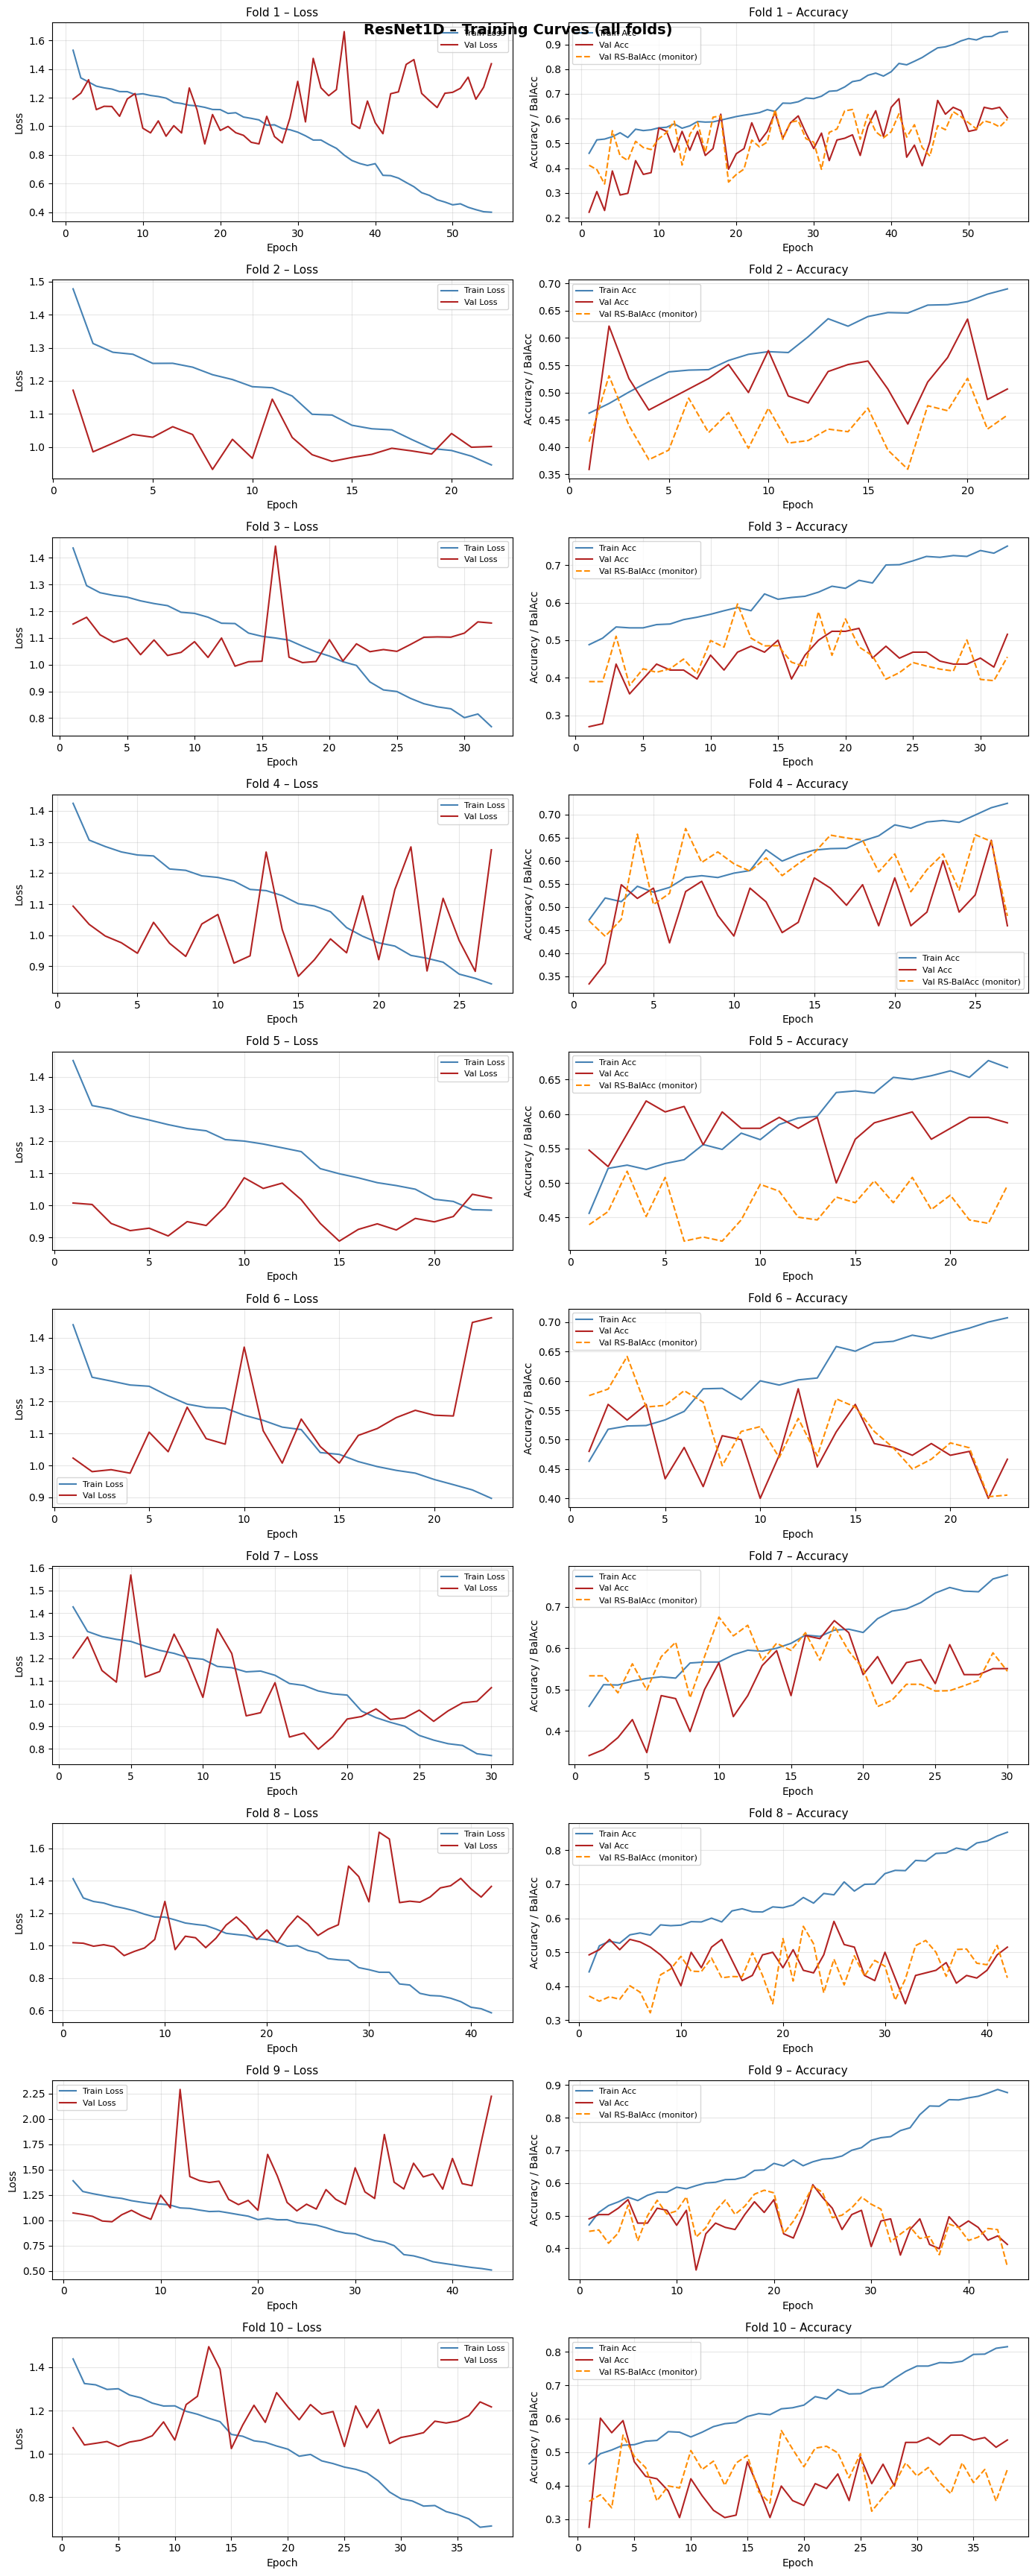

In [138]:
# ResNet1D: Train vs Val Loss & Accuracy per fold
plot_training_curves(resnet_results, 'ResNet1D', save_prefix='resnet1d')

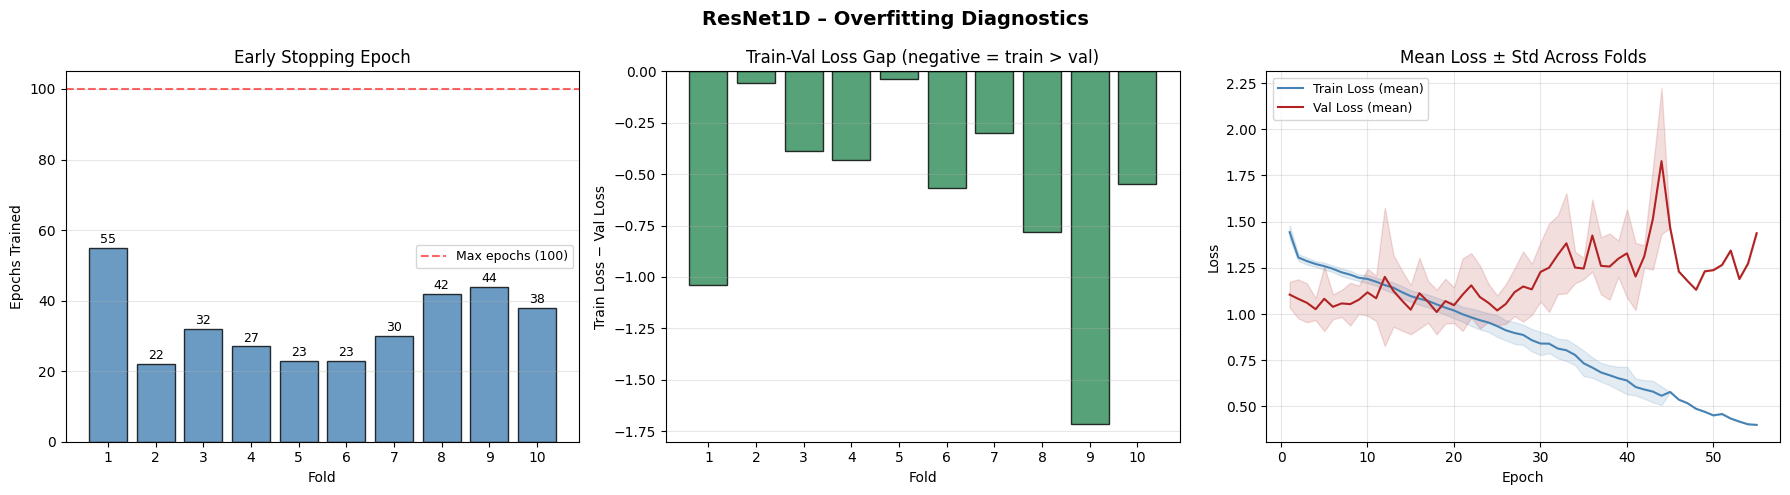

In [139]:
# ResNet1D: Early Stopping Epoch + Train-Val Gap Analysis
plot_overfitting_summary(
    resnet_results, 'ResNet1D',
    max_epochs=CFG['scratch_epochs'],
    save_prefix='resnet1d',
)

#Extended (Multiclass) CTG-Net

CTG-Net architecture is extended to suit the 3 class classification task (normal/mild/severe) to evauate proposed model's performance on multiclassification task.

CTG-Net original model is 2D so they use both FHR and UC signals. Thats why here I added UC pre-processing as they described

In [108]:
def clean_uc(uc_array, fs: int = 4) -> np.ndarray:
    uc = pd.Series(np.array(uc_array, dtype=float))
    uc.replace(0, np.nan, inplace=True)
    uc = uc.interpolate(method='linear')
    uc = uc.ffill().bfill()
    return uc.values

In [110]:
# ── Extract matching UC windows for CTG-Net (2D: FHR + UC) ──
# Uses the same window positions from meta_all to ensure alignment with X_all

def extract_uc_windows(signal_data, metadata, window_length=1800):
    """Extract UC windows matching the FHR windows already extracted."""
    uc_list = []
    for _, row in metadata.iterrows():
        rid = row['rec_id']
        start = row['window_start']
        end = row['window_end']
        uc = np.array(signal_data[rid]['UC'], dtype=np.float64)
        uc_window = uc[start:end]

        # Pad if needed use constant when slice is empty
        if len(uc_window) < window_length:
            pad_len = window_length - len(uc_window)
            pad_mode = 'constant' if len(uc_window) == 0 else 'edge'
            uc_window = np.pad(uc_window, (pad_len, 0), mode=pad_mode)

        # Interpolate any remaining NaN
        if np.any(np.isnan(uc_window)):
            s = pd.Series(uc_window)
            uc_window = s.interpolate(method='linear').ffill().bfill().values

        uc_list.append(uc_window.astype(np.float32))

    X_uc = np.array(uc_list, dtype=np.float32)[:, :, np.newaxis]
    return X_uc

X_uc_all = extract_uc_windows(signal_data, meta_all, window_length=CFG['segment_length'])
print(f"UC windows shape: {X_uc_all.shape}  (should match FHR: {X_all.shape})")

# Stack into 2D input for CTG-Net: (N, 2, 1800, 1)
X_2d_all = np.stack([X_all[:, :, 0], X_uc_all[:, :, 0]], axis=1)[..., np.newaxis]
print(f"CTG-Net 2D input shape: {X_2d_all.shape}")

UC windows shape: (1398, 1800, 1)  (should match FHR: (1398, 1800, 1))
CTG-Net 2D input shape: (1398, 2, 1800, 1)


In [111]:
def build_ctg_net_paper_described(
    input_shape=(2, 1800, 1),
    num_classes: int = 3,
    dropout_rate: float = 0.25,
) -> Model:
    """
    CTG-Net architecture as per Zhao et al., extended to 3-class output.
    """
    inputs = Input(shape=input_shape)

    # Time-direction convolution
    x = Conv2D(
        filters=4,
        kernel_size=(1, 3),
        padding="same",
        use_bias=False,
    )(inputs)
    x = BatchNormalization()(x)

    # Depthwise convolution (captures FHR-UC interactions)
    x = DepthwiseConv2D(
        kernel_size=(2, 1),
        depth_multiplier=2,
        use_bias=False,
    )(x)
    x = BatchNormalization()(x)
    x = Activation("elu")(x)

    # Average pooling + Dropout
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # Separable convolution
    x = SeparableConv2D(
        filters=8,
        kernel_size=(1, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = BatchNormalization()(x)
    x = Activation("elu")(x)

    # Average pooling + Dropout
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # Classification head
    x = Flatten()(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="CTG-Net-2D")
    return model

In [116]:
def normalize_2d_signals(X_2d, norm_stats=None, fit=False):
    """
    Per-channel z-score normalisation for CTG-Net 2D input (N, 2, T, 1).
    If fit=True, computes stats from X_2d and returns (X_normed, stats).
    If fit=False, applies pre-computed stats.
    """
    X_norm = np.zeros_like(X_2d, dtype=np.float32)
    if fit:
        norm_stats = {}
        for ch in range(2):
            vals = X_2d[:, ch, :, 0].ravel()
            m, s = float(np.mean(vals)), float(np.std(vals))
            if s < 1e-8:
                s = 1.0
            norm_stats[ch] = {'mean': m, 'std': s}

    for ch in range(2):
        m = norm_stats[ch]['mean']
        s = norm_stats[ch]['std']
        X_norm[:, ch, :, 0] = (X_2d[:, ch, :, 0] - m) / s

    if fit:
        return X_norm, norm_stats
    return X_norm

In [117]:
def evaluate_ctg_net_2d_outer_folds(
    build_fn,
    X_2d: np.ndarray,
    y: np.ndarray,
    metadata: pd.DataFrame,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    model_name: str = "CTG-Net",
    epochs: int = 100,
    batch_size: int = 16,
    patience: int = 20,
    lr: float = 1e-3,
    label_smoothing: float = 0.05,
) -> List[dict]:
    """
    Evaluate the 2D CTG-Net (FHR+UC) fold-by-fold with fixed class weights.
    Uses per-channel z-score normalisation (train-fold only).
    No augmentation (paper does not describe any).
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n  {model_name} - Fold {fold_idx + 1}/{len(folds)}")

        X_tr = X_2d[train_idx]
        X_va = X_2d[val_idx]
        y_tr = y[train_idx]
        y_va = y[val_idx]
        meta_val = meta.iloc[val_idx].reset_index(drop=True)

        # Per-channel z-score normalisation (fit on train only)
        X_tr_n, ch_stats = normalize_2d_signals(X_tr, fit=True)
        X_va_n = normalize_2d_signals(X_va, norm_stats=ch_stats, fit=False)

        class_weight = FIXED_CLASS_WEIGHT.copy()

        y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
        y_va_cat = to_categorical(y_va, NUM_CLASSES)

        compile_kwargs = dict(
            optimizer=Adam(learning_rate=lr),
            loss=tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=label_smoothing
            ),
            metrics=['accuracy'],
        )

        rs_callback = RecordStepBalancedAccuracy(
            X_val=X_va_n,
            val_metadata=meta_val,
            batch_size=32,
        )

        callbacks = get_callbacks(
            patience=patience,
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            prefix_callbacks=[rs_callback],
            save_weights_only=True,
        )

        fit_kwargs = dict(
            x=X_tr_n,
            y=y_tr_cat,
            validation_data=(X_va_n, y_va_cat),
            epochs=epochs,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
        )

        model, history, used_batch_size = fit_model_with_batch_backoff(
            model_builder=build_fn,
            compile_kwargs=compile_kwargs,
            fit_kwargs=fit_kwargs,
            initial_batch_size=int(batch_size),
        )

        y_proba_val = model.predict(X_va_n, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['history'] = history.history
        fold_results.append(metrics)

        print(
            f"batch={used_batch_size}  "
            f"Acc={metrics['accuracy']:.4f}  "
            f"BalAcc={metrics['balanced_accuracy']:.4f}  "
            f"F1={metrics['macro_f1']:.4f}  "
            f"R_N={metrics['recall_Normal']:.3f}  "
            f"R_M={metrics['recall_Mild']:.3f}  "
            f"R_S={metrics['recall_Severe']:.3f}"
        )

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    return fold_results

In [118]:
# CTG-Net 2D outer fold evaluation (same folds as ResNet1D / sklearn baselines)
print("CTG-Net 2D (Zhao et al.): evaluating across all outer folds")
print(f"  Input shape: {X_2d_all.shape}")
print(f"  Manual class weights: {dict(FIXED_CLASS_WEIGHT)}")

ctg_net_build_fn = lambda: build_ctg_net_paper_described(
    input_shape=(2, CFG['segment_length'], 1),
    num_classes=NUM_CLASSES,
    dropout_rate=0.25,
)

CTG-Net 2D (Zhao et al.) – evaluating across all outer folds
  Input shape: (1398, 2, 1800, 1)
  Manual class weights: {0: 0.9, 1: 1.2, 2: 2.5}


In [119]:
ctg_net_results = evaluate_ctg_net_2d_outer_folds(
    build_fn=ctg_net_build_fn,
    X_2d=X_2d_all,
    y=y_all,
    metadata=meta_all,
    folds=baseline_folds,
    model_name="CTG-Net",
    epochs=CFG['scratch_epochs'],
    batch_size=CFG['scratch_batch'],
    patience=CFG['scratch_patience'],
    lr=1e-3,
    label_smoothing=CFG.get('label_smoothing', 0.05),
)


  CTG-Net - Fold 1/10
  val_record_step_balanced_accuracy: 0.4999
  val_record_step_balanced_accuracy: 0.4833
  val_record_step_balanced_accuracy: 0.5166
  val_record_step_balanced_accuracy: 0.5924
  val_record_step_balanced_accuracy: 0.6398
  val_record_step_balanced_accuracy: 0.6343
  val_record_step_balanced_accuracy: 0.5589
  val_record_step_balanced_accuracy: 0.5728
  val_record_step_balanced_accuracy: 0.5193
  val_record_step_balanced_accuracy: 0.5532
  val_record_step_balanced_accuracy: 0.5391
  val_record_step_balanced_accuracy: 0.4719
  val_record_step_balanced_accuracy: 0.5056
  val_record_step_balanced_accuracy: 0.4441
  val_record_step_balanced_accuracy: 0.4917

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
  val_record_step_balanced_accuracy: 0.5393
  val_record_step_balanced_accuracy: 0.5056
  val_record_step_balanced_accuracy: 0.4803
  val_record_step_balanced_accuracy: 0.5058
  val_record_step_balanced_accuracy: 0.4525
  val_record_step_b

In [120]:
ctg_net_summary = summarise_fold_results(ctg_net_results, "CTG-Net (Zhao et al.)")

In [121]:
print(
    f"\nCTG-Net (Zhao et al.): Macro F1: "
    f"{ctg_net_summary['macro_f1_mean']:.4f} +/- {ctg_net_summary['macro_f1_std']:.4f}"
)
print(
    f"Balanced Accuracy: "
    f"{ctg_net_summary['balanced_accuracy_mean']:.4f} +/- {ctg_net_summary['balanced_accuracy_std']:.4f}"
)
print(
    f"Recall Normal={ctg_net_summary['normal_recall_mean']:.4f}, "
    f"Mild={ctg_net_summary['mild_recall_mean']:.4f}, "
    f"Severe={ctg_net_summary['severe_recall_mean']:.4f}"
)


CTG-Net (Zhao et al.): Macro F1: 0.5234 +/- 0.0805
Balanced Accuracy: 0.5527 +/- 0.0590
Recall Normal=0.6426, Mild=0.4910, Severe=0.5246


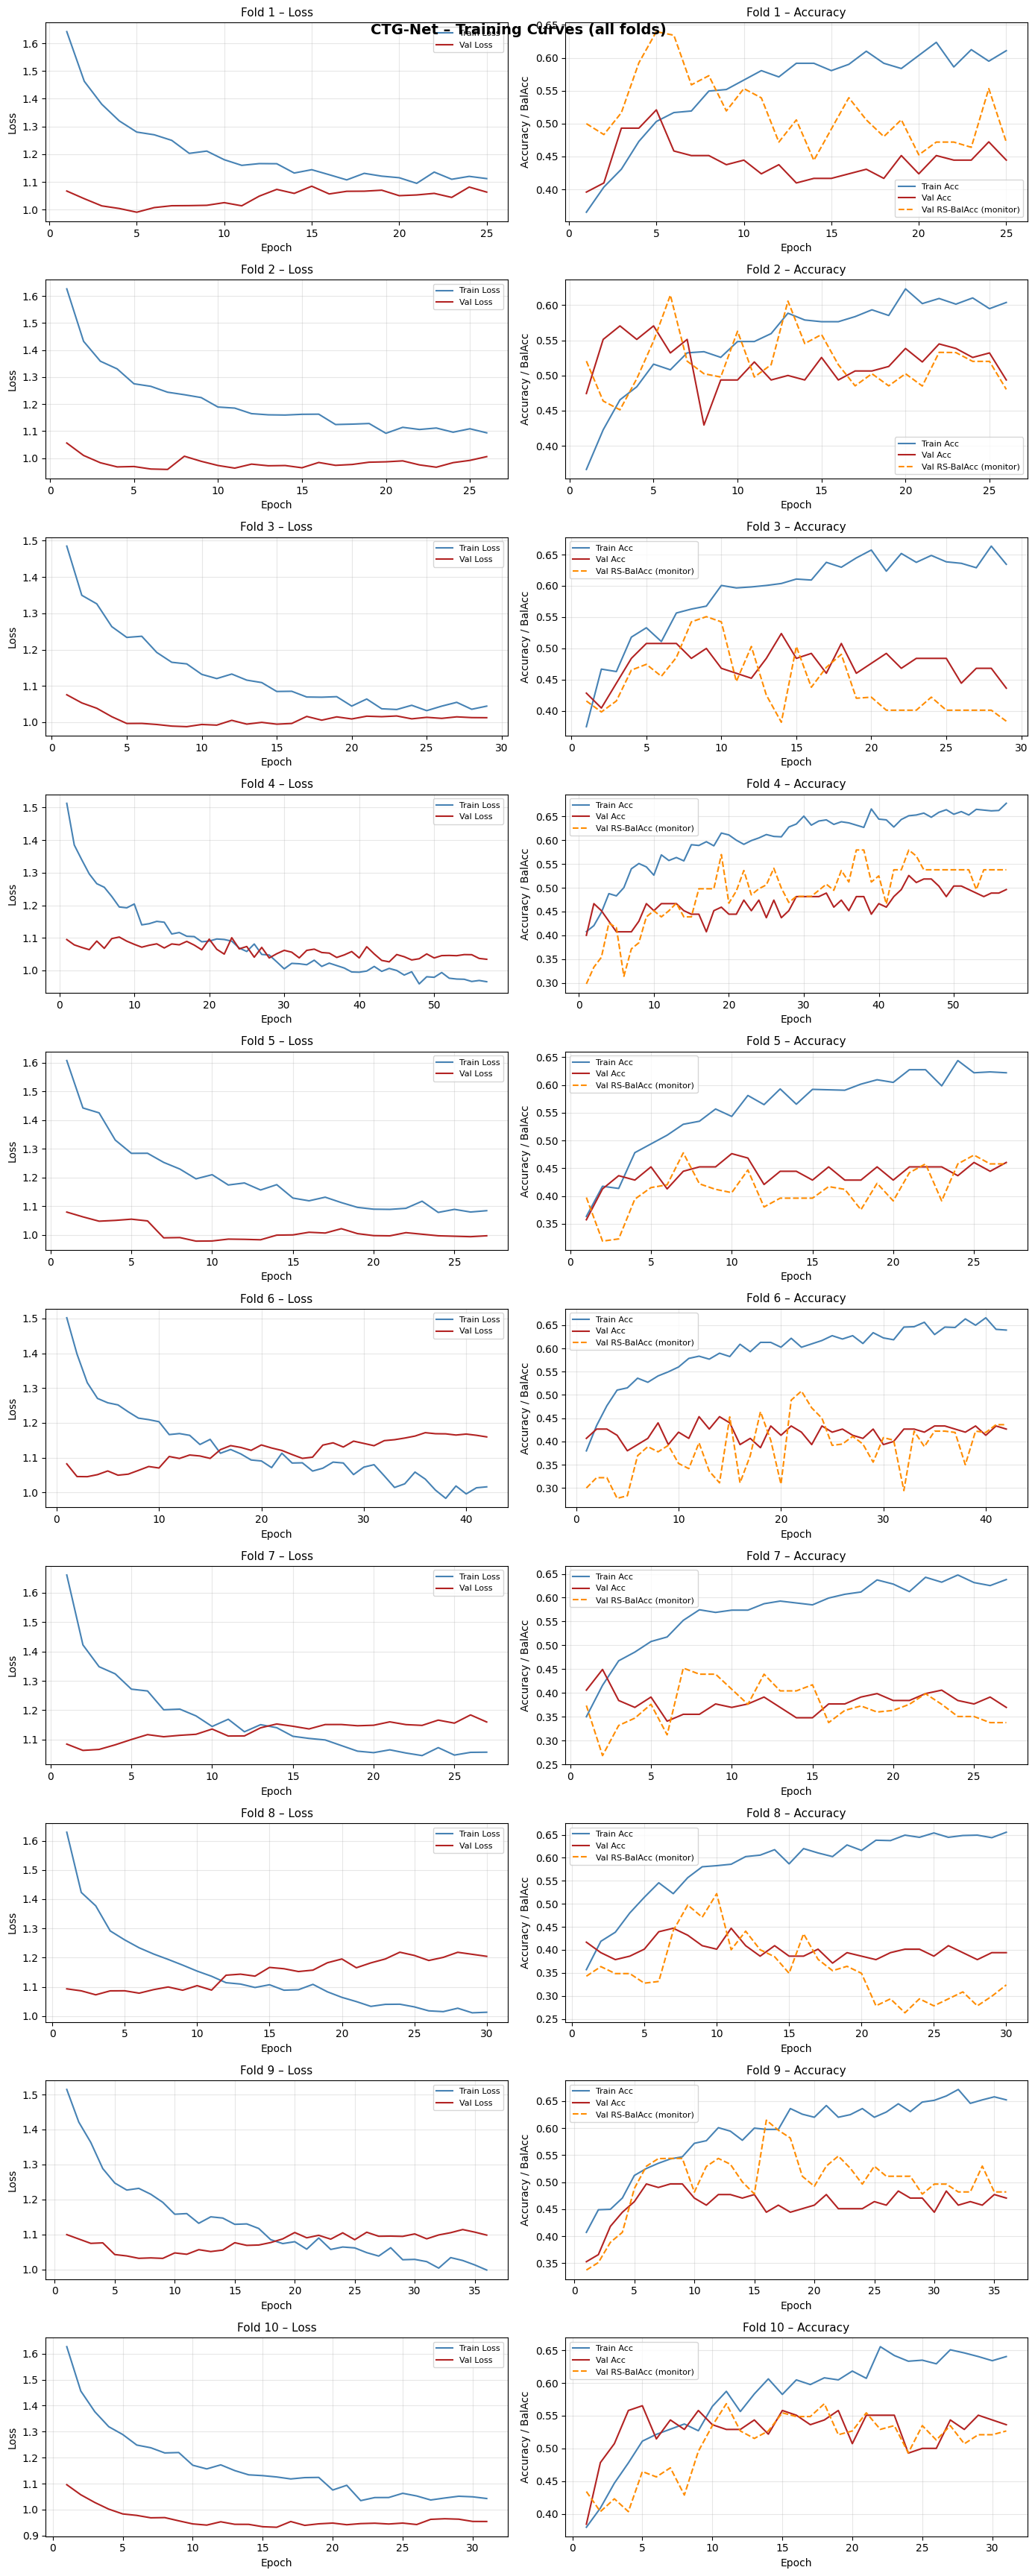

In [122]:
# CTG-Net: Train vs Val Loss & Accuracy per fold
plot_training_curves(ctg_net_results, 'CTG-Net', save_prefix='ctg_net')

In [ ]:
# CTG-Net: Train vs Val Loss & Accuracy per fold
plot_training_curves(ctg_net_results, 'CTG-Net', save_prefix='ctg_net')

In [ ]:
# CTG-Net: Early Stopping Epoch + Train-Val Gap Analysis
plot_overfitting_summary(
    ctg_net_results, 'CTG-Net',
    max_epochs=CFG['scratch_epochs'],
    save_prefix='ctg_net',
)

# Visualisations

In [142]:
# Build the final summary for the hybrid CNN from scratch_results
final_summary = summarise_fold_results(scratch_results, 'Hybrid CNN (FHR-SegNet + Clinical)')

all_summaries = [lr_summary, svm_summary, rf_summary, resnet_summary, ctg_net_summary, final_summary]
comparison_df = pd.DataFrame(all_summaries).set_index('model')

display_rows = []
for model_name in comparison_df.index:
    row = comparison_df.loc[model_name]
    display_rows.append({
        'Model': model_name,
        'Accuracy': f"{row['accuracy_mean']:.4f} +/- {row['accuracy_std']:.4f}",
        'Bal. Accuracy': f"{row['balanced_accuracy_mean']:.4f} +/- {row['balanced_accuracy_std']:.4f}",
        'Macro F1': f"{row['macro_f1_mean']:.4f} +/- {row['macro_f1_std']:.4f}",
        'Normal Recall': f"{row['normal_recall_mean']:.4f}",
        'Mild Recall': f"{row['mild_recall_mean']:.4f}",
        'Severe Recall': f"{row['severe_recall_mean']:.4f}",
    })
display_df = pd.DataFrame(display_rows).set_index('Model')
print('\nMODEL COMPARISON -- Record-Step Level (mean +/- std across folds)')
print(display_df.to_string())

comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv')
display_df.to_csv(OUTPUT_DIR / 'model_comparison_formatted.csv')
print(f'\nSaved to {OUTPUT_DIR}')


MODEL COMPARISON -- Record-Step Level (mean +/- std across folds)
                                                  Accuracy      Bal. Accuracy           Macro F1 Normal Recall Mild Recall Severe Recall
Model                                                                                                                                   
Logistic Regression                      0.5196 +/- 0.0742  0.5378 +/- 0.0813  0.4902 +/- 0.0682        0.6692      0.3668        0.5774
SVM                                      0.5966 +/- 0.0524  0.4605 +/- 0.0511  0.4284 +/- 0.0485        0.6416      0.7274        0.0125
Random Forest                            0.5783 +/- 0.0582  0.5093 +/- 0.0771  0.5115 +/- 0.0726        0.6417      0.6015        0.2848
ResNet1D (grouped-tuned, fixed-weights)  0.5837 +/- 0.0632  0.5999 +/- 0.0522  0.5440 +/- 0.0527        0.7253      0.4406        0.6339
CTG-Net (Zhao et al.)                    0.5604 +/- 0.0917  0.5527 +/- 0.0590  0.5234 +/- 0.0805        0.6426 

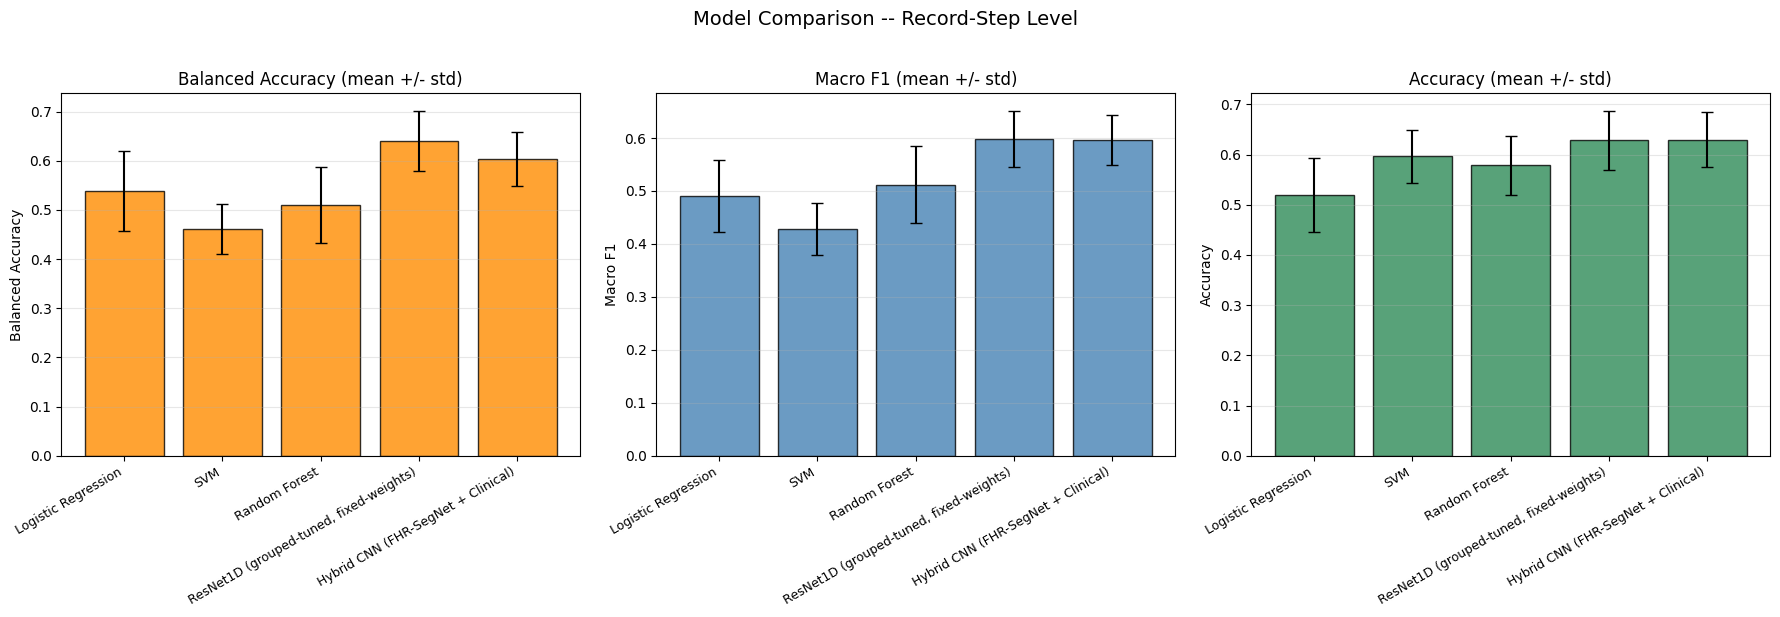

In [74]:
# Bar plot comparison
model_names = comparison_df.index.tolist()
x_pos = np.arange(len(model_names))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metric_info = [
    ('balanced_accuracy_mean', 'balanced_accuracy_std', 'Balanced Accuracy', 'darkorange'),
    ('macro_f1_mean', 'macro_f1_std', 'Macro F1', 'steelblue'),
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'seagreen'),
]
for ax, (mean_col, std_col, title, color) in zip(axes, metric_info):
    ax.bar(x_pos, comparison_df[mean_col], yerr=comparison_df[std_col], capsize=4,
           color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'{title} (mean +/- std)')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Model Comparison -- Record-Step Level', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'model_comparison_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

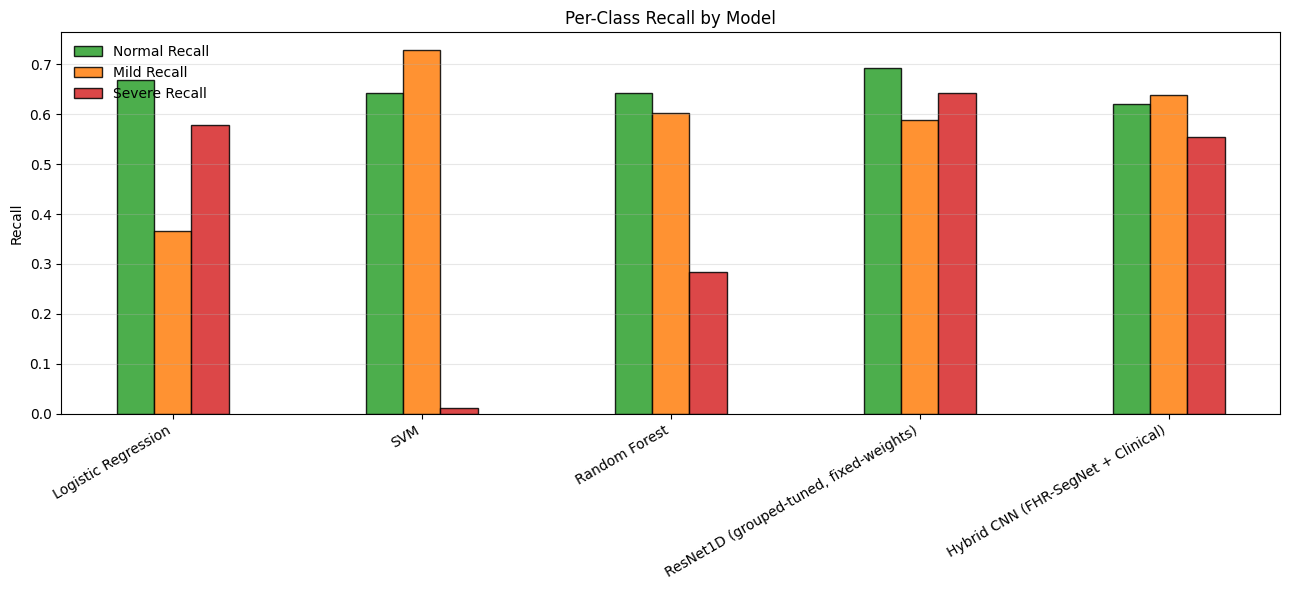


Model comparison complete.


In [75]:
# Per-class recall comparison
fig2, ax2 = plt.subplots(figsize=(13, 6))
bar_width = 0.15
class_colors = {'Normal': '#2ca02c', 'Mild': '#ff7f0e', 'Severe': '#d62728'}
for i, cls_name in enumerate(CLASS_NAMES):
    col = f'{cls_name.lower()}_recall_mean'
    offset = (i - 1) * bar_width
    ax2.bar(x_pos + offset, comparison_df[col], width=bar_width,
            label=f'{cls_name} Recall', color=class_colors[cls_name], edgecolor='black', alpha=0.85)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(model_names, rotation=30, ha='right', fontsize=10)
ax2.set_ylabel('Recall')
ax2.set_title('Per-Class Recall by Model')
ax2.legend(frameon=False)
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / 'model_comparison_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nModel comparison complete.')

# 15. Per-Model Fold-Level Plots

Collect all experiment results into a single dict, then plot each model independently.

In [76]:
# Collect all experiment results
ALL_EXPERIMENT_RESULTS = {}

if 'scratch_results' in globals():
    ALL_EXPERIMENT_RESULTS['Hybrid CNN (FHR-SegNet + Clinical)'] = {'fold_results': scratch_results}
if 'lr_results' in globals():
    ALL_EXPERIMENT_RESULTS['Logistic Regression'] = {'fold_results': lr_results}
if 'svm_results' in globals():
    ALL_EXPERIMENT_RESULTS['SVM'] = {'fold_results': svm_results}
if 'rf_results' in globals():
    ALL_EXPERIMENT_RESULTS['Random Forest'] = {'fold_results': rf_results}
if 'resnet_results' in globals():
    ALL_EXPERIMENT_RESULTS['ResNet1D'] = {'fold_results': resnet_results}

print(f"Collected results for: {list(ALL_EXPERIMENT_RESULTS.keys())}")

Collected results for: ['Hybrid CNN (FHR-SegNet + Clinical)', 'Logistic Regression', 'SVM', 'Random Forest', 'ResNet1D']


In [140]:
def plot_fold_metrics(model_name, fold_results, save=True):
    """Plot fold-level Macro F1, Balanced Accuracy, and Severe Recall for a single model."""
    metric_keys = [
        ('Macro F1', 'macro_f1'),
        ('Balanced Accuracy', 'balanced_accuracy'),
        ('Recall - Severe', 'recall_Severe'),
    ]
    folds = list(range(1, len(fold_results) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['steelblue', 'darkorange', 'firebrick']

    for ax, (label, key), color in zip(axes, metric_keys, colors):
        vals = [r[key] for r in fold_results]
        mean_val = np.mean(vals)
        ax.plot(folds, vals, marker='o', color=color, alpha=0.8, label=f'{label} per fold')
        ax.axhline(mean_val, linestyle='--', color=color, alpha=0.5,
                   label=f'Mean = {mean_val:.4f}')
        ax.set_title(label, fontsize=13)
        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_xticks(folds)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(f'{model_name} - Fold-Level Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save:
        safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '_')
        fig.savefig(OUTPUT_DIR / f'{safe_name}_fold_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

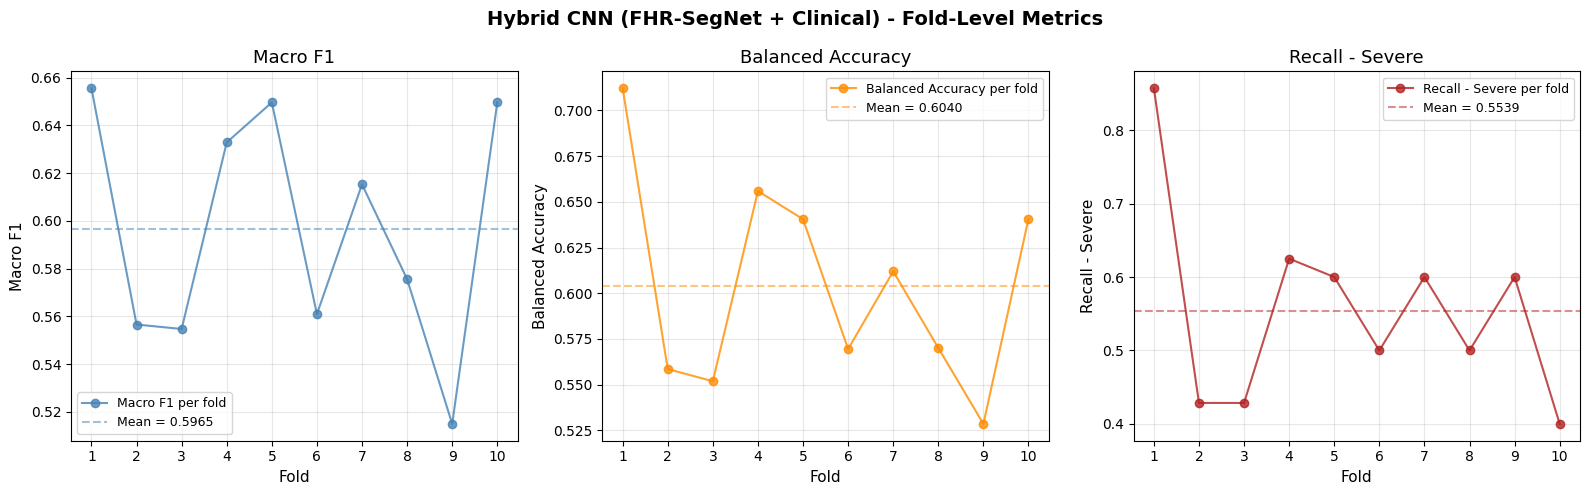

In [78]:
# Hybrid CNN fold-level plot
if 'Hybrid CNN (FHR-SegNet + Clinical)' in ALL_EXPERIMENT_RESULTS:
    plot_fold_metrics('Hybrid CNN (FHR-SegNet + Clinical)',
                      ALL_EXPERIMENT_RESULTS['Hybrid CNN (FHR-SegNet + Clinical)']['fold_results'])

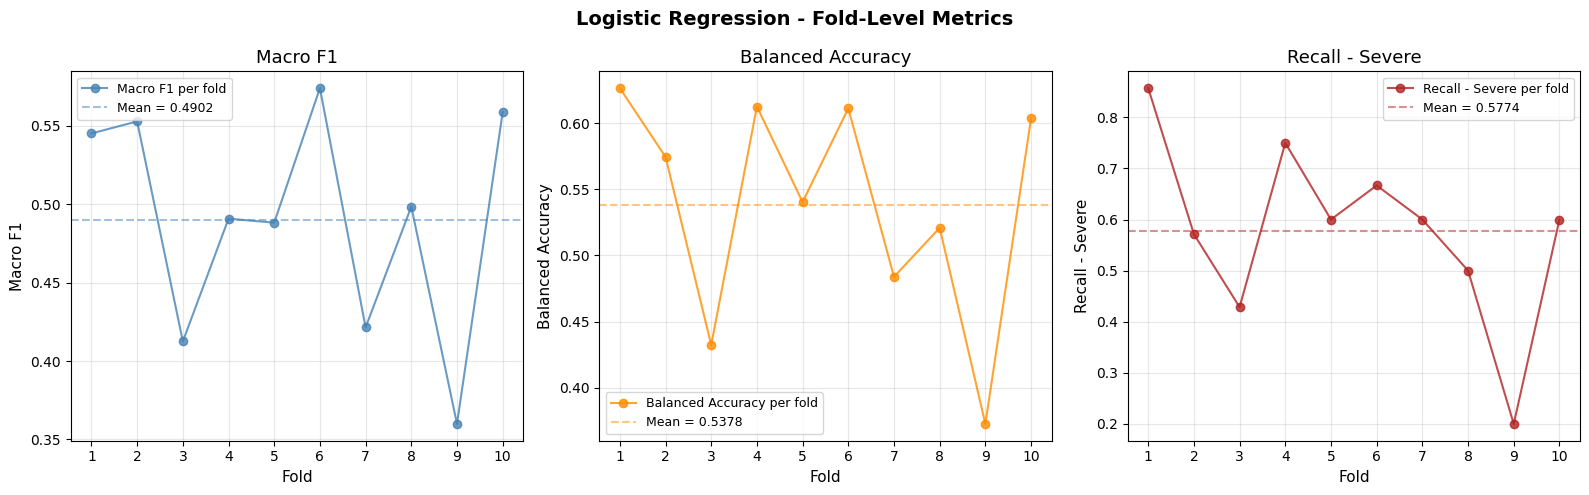

In [79]:
# Logistic Regression fold-level plot
if 'Logistic Regression' in ALL_EXPERIMENT_RESULTS:
    plot_fold_metrics('Logistic Regression',
                      ALL_EXPERIMENT_RESULTS['Logistic Regression']['fold_results'])

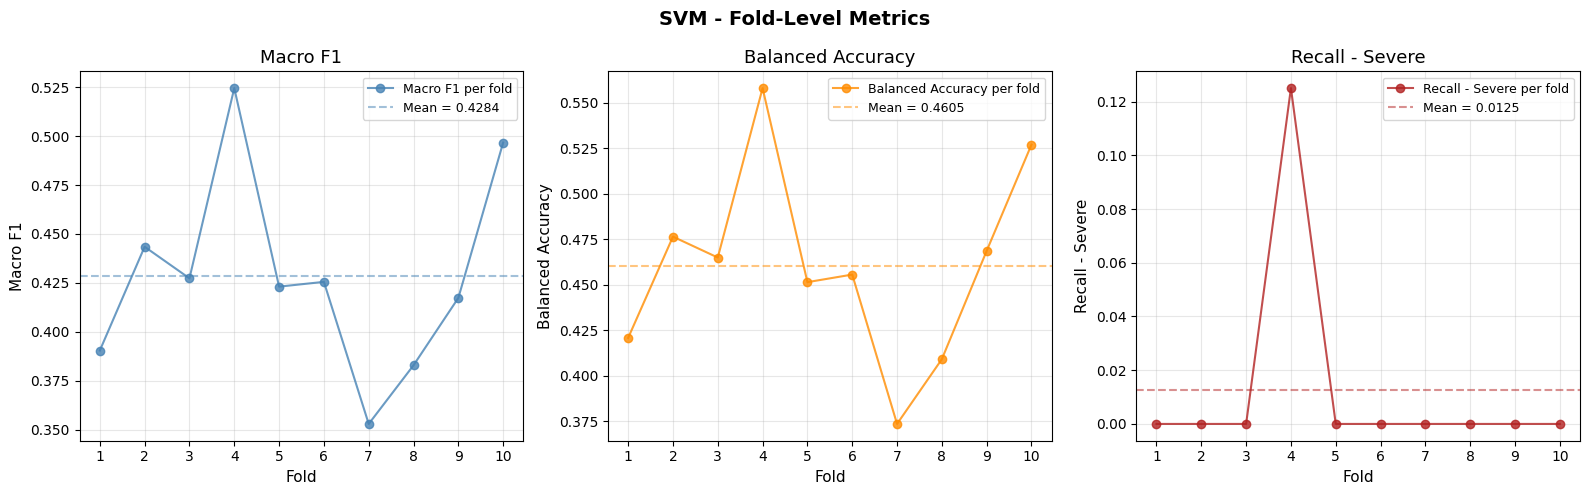

In [80]:
# SVM fold-level plot
if 'SVM' in ALL_EXPERIMENT_RESULTS:
    plot_fold_metrics('SVM',
                      ALL_EXPERIMENT_RESULTS['SVM']['fold_results'])

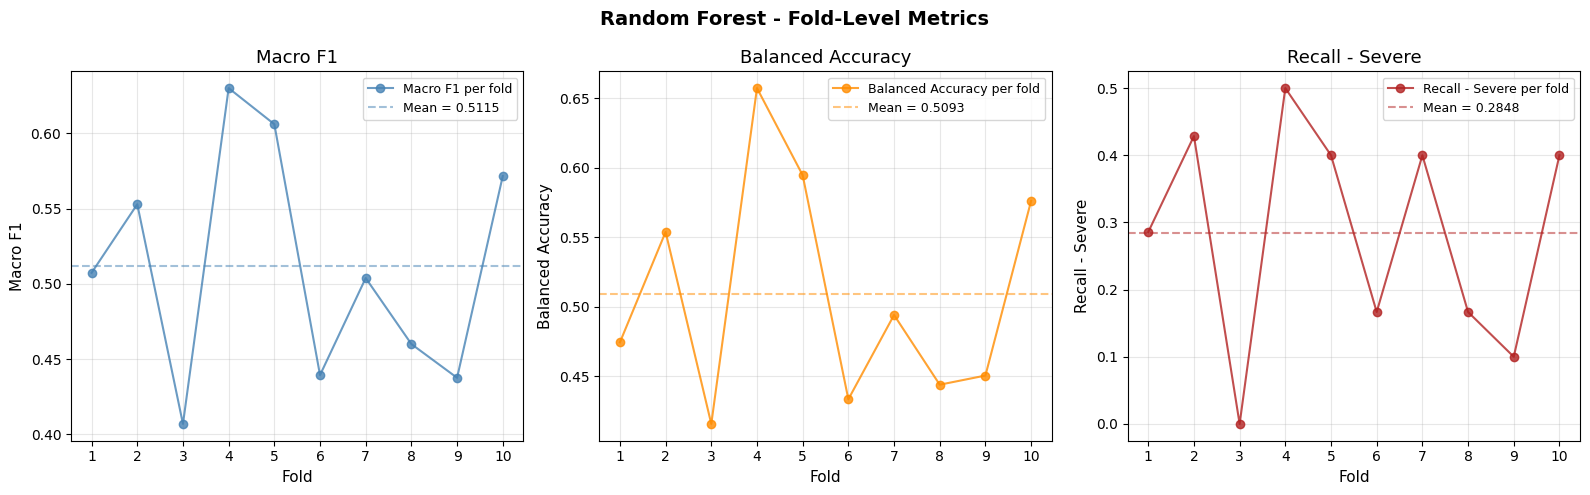

In [81]:
# Random Forest fold-level plot
if 'Random Forest' in ALL_EXPERIMENT_RESULTS:
    plot_fold_metrics('Random Forest',
                      ALL_EXPERIMENT_RESULTS['Random Forest']['fold_results'])

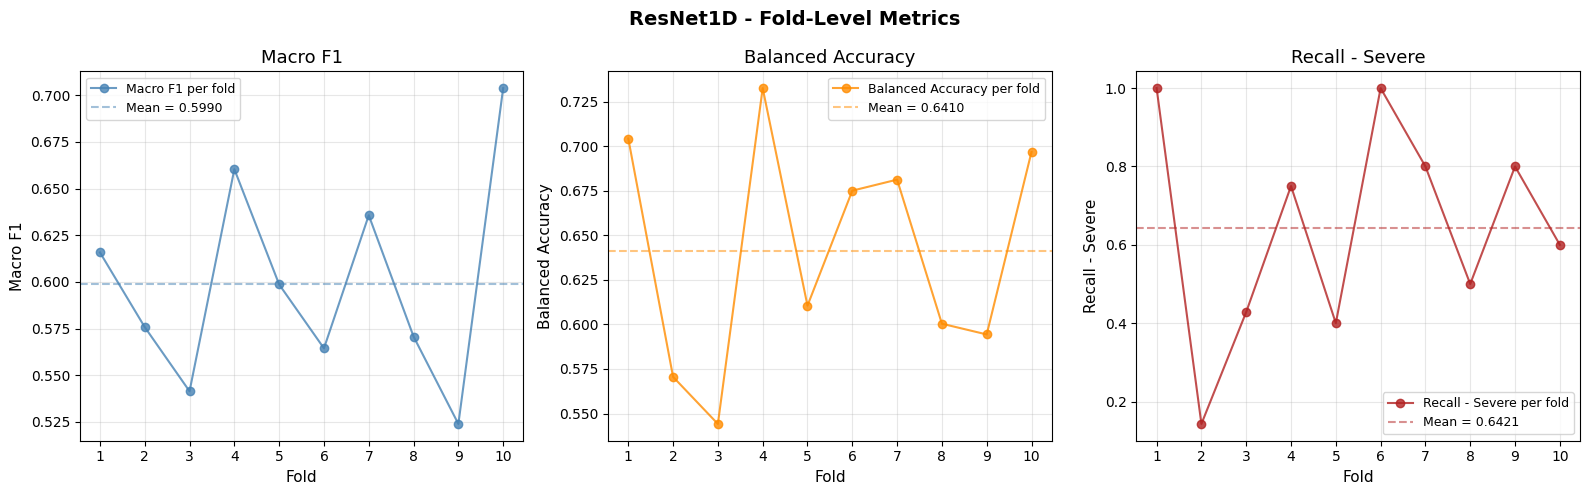

In [82]:
# ResNet1D fold-level plot
if 'ResNet1D' in ALL_EXPERIMENT_RESULTS:
    plot_fold_metrics('ResNet1D',
                      ALL_EXPERIMENT_RESULTS['ResNet1D']['fold_results'])

In [ ]:
if 'ctg_net_results' in globals():
    ALL_EXPERIMENT_RESULTS['CTG-Net'] = {'fold_results': ctg_net_results}


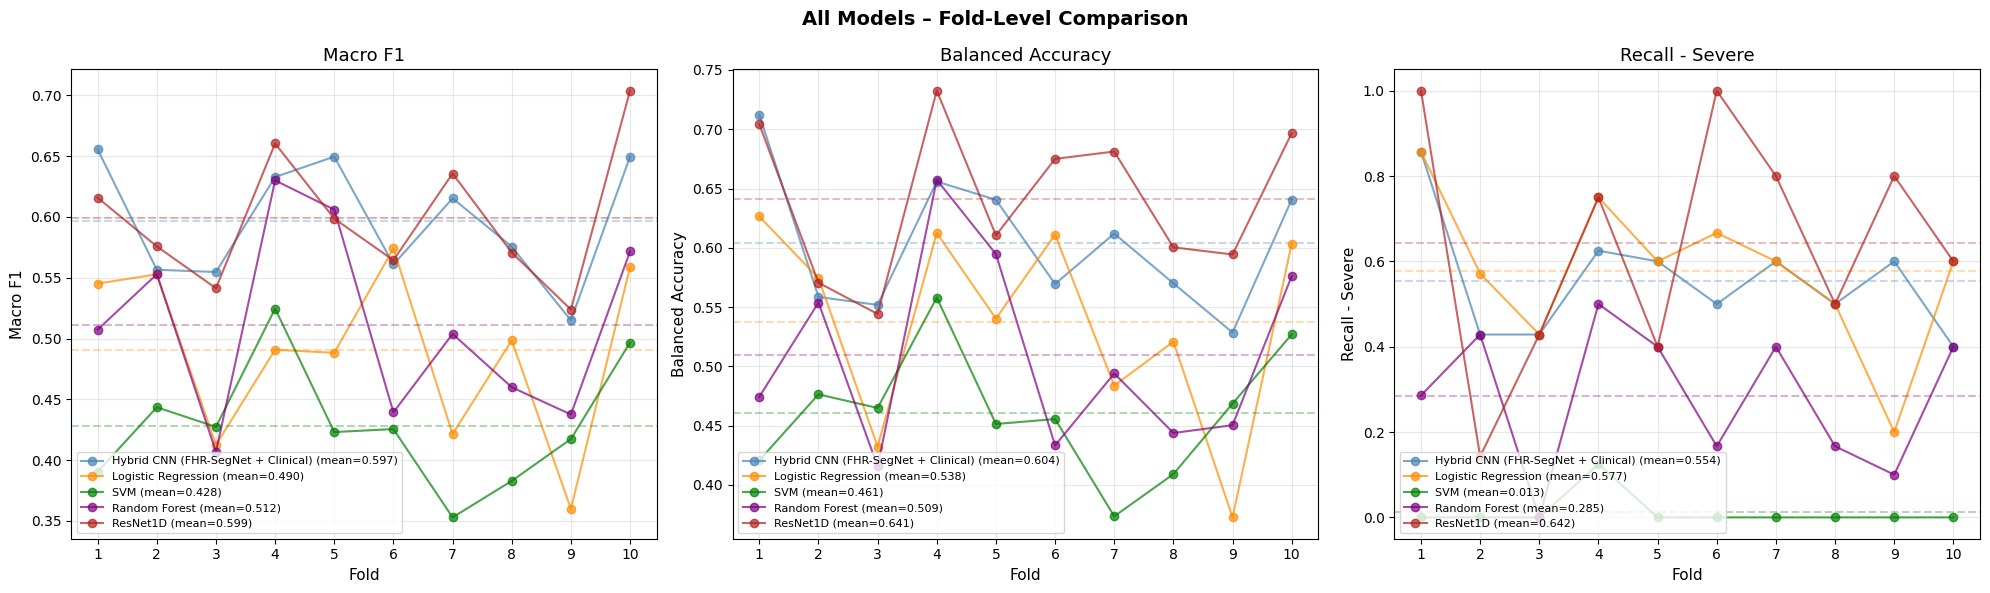

In [141]:
# Combined fold-level plot: all models on the same axes
metric_keys = [
    ('Macro F1', 'macro_f1'),
    ('Balanced Accuracy', 'balanced_accuracy'),
    ('Recall - Severe', 'recall_Severe'),
]

model_colors = {
    'Hybrid CNN (FHR-SegNet + Clinical)': 'steelblue',
    'Logistic Regression': 'darkorange',
    'SVM': 'green',
    'Random Forest': 'purple',
    'ResNet1D': 'firebrick',
    'CTG-Net': 'teal',
}

available = {k: v for k, v in ALL_EXPERIMENT_RESULTS.items() if 'fold_results' in v}
if not available:
    print("No fold results collected yet.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for ax, (label, key) in zip(axes, metric_keys):
        for model_name, entry in available.items():
            fold_results = entry['fold_results']
            folds = list(range(1, len(fold_results) + 1))
            vals = [r[key] for r in fold_results]
            mean_val = np.mean(vals)
            color = model_colors.get(model_name, 'grey')

            ax.plot(folds, vals, marker='o', color=color, alpha=0.7,
                    label=f'{model_name} (mean={mean_val:.3f})')
            ax.axhline(mean_val, linestyle='--', color=color, alpha=0.3)

        ax.set_title(label, fontsize=13)
        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_xticks(folds)
        ax.legend(fontsize=8, loc='lower left')
        ax.grid(alpha=0.3)

    plt.suptitle('All Models – Fold-Level Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'all_models_fold_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()